# 06. Per-Variable Observability Investigation

This notebook investigates the remaining per-variable observability questions in the measured planar-rover pipeline. It uses the simulated noisy sensor measurements and `dataset.window_jacobians(...)`; it does not construct a second nominal or noise-free Jacobian.

The core distinction is between nonzero numerical sensitivity, effective rank, absolute physical information strength, and practical uncertainty. The notebook keeps raw, physical, projected, filtered, and column-normalized matrices as separate named objects.


## 1. Purpose of the Investigation

The mathematical object is the rolling measured Jacobian `J in R^(m x n)`, partitioned as trajectory columns `J_T` and calibration columns `J_C`. For each target `X`, we check direct sensitivity `J_X`, nuisance-projected sensitivity `O_X`, rank, information, and uncertainty.

Theoretical behavior: nuisance projection should satisfy `rank(O_X) <= rank(J_X)` and `||O_X||_F <= ||J_X||_F`; gyro-only IMU factors should have zero `T_B_I` translation columns; scalar time-offset rank should be replaced by physical sensitivity. A numerical problem is indicated by rank/norm inequality violations, nonzero gyro translation columns, dense/sparse disagreement, or ranks caused only by near-zero leakage after normalization.


## 2. Imports and Configuration

This cell exposes all thresholds and the Jacobian mode near the top of the notebook. Later matrices are raw/whitened as assembled by the measured pipeline, optionally physically scaled by `PARAMETER_SCALES`, projected, filtered, or column-normalized only when explicitly named.

Expected behavior: `JACOBIAN_METHOD = "analytic_checked"` validates analytic measured Jacobian blocks against finite differences. A failure here means the measured Jacobian pipeline itself needs attention before interpreting ranks.


In [22]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import sparse

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

from calib_observability.backend import estimate_poses_dummy
from calib_observability.diagnostics import (
    common_rank_diagnostics,
    physical_information_diagnostics,
    reject_and_normalize_columns_dense,
    reject_and_normalize_columns_sparse,
)
from calib_observability.factor_observability import (
    SUPPORTED_CALIBRATION_VARIABLES,
    build_lidar_motion_only_matrix_dense,
    effective_target_observability_from_bundle_sparse,
)
from calib_observability.jacobians import linearize_gyro_factor
from calib_observability.scaling import ParameterScales, build_parameter_scaling_dense
from calib_observability.simulation import PlanarRoverConfig, simulate_planar_rover
from calib_observability.types import JacobianOptions

FIXED_EXTRINSIC = "none"
JACOBIAN_METHOD = "analytic"
WINDOW_DURATION = 5.0
WINDOW_STEP = 1.0
RELATIVE_RANK_THRESHOLD = 1e-5
ABSOLUTE_ZERO_TOLERANCE = 1e-6
RELATIVE_ZERO_TOLERANCE = 1e-5
TAU_I_SENSITIVITY_THRESHOLD = 1e-3
TAU_L_SENSITIVITY_THRESHOLD = 1e-3
MAX_ACCEPTABLE_TAU_I_STD_SECONDS = 0.01
MAX_ACCEPTABLE_TAU_L_STD_SECONDS = 0.01
SELECTED_DEBUG_TIMES = [5.0, 12.0, 23.0, 38.0, 54.0]
OUTPUT_DIRECTORY = ROOT / "outputs" / "per_variable_observability_investigation"
MATRIX_OUTPUT_DIRECTORY = OUTPUT_DIRECTORY / "matrices"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
MATRIX_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

JACOBIAN_OPTIONS = JacobianOptions(
    method=JACOBIAN_METHOD,
    finite_difference_epsilon=1e-7,
    check_atol=1e-6,
    check_rtol=1e-5,
    raise_on_check_failure=True,
)

RECTANGLE_COUNT = 2
RECTANGLE_WIDTH = 8.0
RECTANGLE_HEIGHT = 5.0
STRAIGHT_SPEED = 1.0
TURN_DURATION = 1.5
IMU_RATE_HZ = 100.0
LIDAR_RATE_HZ = 5.0
RANDOM_SEED = 52

# Keep the strict requested check as the first attempt. If one window fails
# only the check tolerance, rerun with non-raising checked mode and record it.
ALLOW_NONRAISING_ANALYTIC_CHECK_RETRY = True

PARAMETER_SCALES = ParameterScales(
    rotation_scale_rad=1.0,
    translation_scale_m=1.0,
    gyro_bias_scale_rad_s=1.0,
    time_offset_scale_s=1.0,
)

print(json.dumps({
    "jacobian_method": JACOBIAN_METHOD,
    "window_duration": WINDOW_DURATION,
    "window_step": WINDOW_STEP,
    "relative_rank_threshold": RELATIVE_RANK_THRESHOLD,
    "absolute_zero_tolerance": ABSOLUTE_ZERO_TOLERANCE,
    "relative_zero_tolerance": RELATIVE_ZERO_TOLERANCE,
    "output_directory": str(OUTPUT_DIRECTORY),
}, indent=2))


{
  "jacobian_method": "analytic",
  "window_duration": 5.0,
  "window_step": 1.0,
  "relative_rank_threshold": 1e-05,
  "absolute_zero_tolerance": 1e-06,
  "relative_zero_tolerance": 1e-05,
  "output_directory": "/home/camel/Skoltech/phd_proposal/outputs/per_variable_observability_investigation"
}


## 3. Simulation and Measured Jacobian Pipeline

This cell constructs the same noisy measured planar-rover dataset used by the quasi-realtime animation: rectangular laps, IMU and LiDAR timestamps, true calibration values, and the dummy true-pose provider. The later Jacobians are assembled from these measured signals only.

Expected behavior: sensor rates and noise values should match the simulation configuration. A problem is indicated by zero covariance, because whitening requires positive-definite covariance matrices.


In [23]:
rover_mode = "multiple_rectangles" if RECTANGLE_COUNT > 1 else "one_rectangle"
rover_config = PlanarRoverConfig(
    rectangle_width=RECTANGLE_WIDTH,
    rectangle_height=RECTANGLE_HEIGHT,
    straight_speed=STRAIGHT_SPEED,
    turn_duration=TURN_DURATION,
    total_laps=RECTANGLE_COUNT,
    imu_rate_hz=IMU_RATE_HZ,
    lidar_rate_hz=LIDAR_RATE_HZ,
    random_seed=RANDOM_SEED,
    mode=rover_mode,
)
dataset = simulate_planar_rover(rover_config, mode=rover_mode)
pose_provider = estimate_poses_dummy(dataset)

print(f"trajectory mode: {dataset.trajectory.mode}")
print(f"time range: [{dataset.start_time:.2f}, {dataset.end_time:.2f}] s")
print(f"IMU samples: {dataset.imu.sensor_timestamps.size}")
print(f"LiDAR factors: {dataset.lidar.relative_start_times.size}")
print("sensor noise std:", {
    "gyro": rover_config.gyro_noise_std,
    "accel": rover_config.accel_noise_std,
    "lidar_pose": rover_config.lidar_pose_noise_std,
})


trajectory mode: multiple_rectangles
time range: [0.00, 64.00] s
IMU samples: 6401
LiDAR factors: 320
sensor noise std: {'gyro': 0.002, 'accel': 0.03, 'lidar_pose': (0.005, 0.005, 0.005, 0.02, 0.02, 0.02)}


## 4. Matrix-Version and Notation Summary

For each target `X`, `J_X_raw` is extracted from measured `J_C`; `J_X_physical` is whitened and physically scaled; `O_X_physical` is projected against trajectory and calibration nuisance variables; `O_X_filtered` sets rejected near-zero columns exactly to zero; `O_X_normalized` is a diagnostic matrix for comparing independent directions.

Dimensions: if `J in R^(m x n)`, target `J_X in R^(m x n_X)`, nuisance `J_N in R^(m x n_N)`, and projected `O_X in R^(m x n_X)`. A problem is indicated if one version silently overwrites another or if uncertainty is computed from a normalized matrix.


In [24]:
VARIABLE_DIMENSIONS = {"T_B_I": 6, "T_B_L": 6, "b_g": 3, "tau_I": 1, "tau_L": 1}
VARIABLE_LABELS = {
    "T_B_I": ["rot_x", "rot_y", "rot_z", "x", "y", "z"],
    "T_B_L": ["rot_x", "rot_y", "rot_z", "x", "y", "z"],
    "b_g": ["b_gx", "b_gy", "b_gz"],
    "tau_I": ["tau_I"],
    "tau_L": ["tau_L"],
}
MATRIX_VERSION_DEFINITIONS = pd.DataFrame([
    {"name": "J_X_raw", "meaning": "target columns from measured J_C", "normalization": "raw whitened"},
    {"name": "J_X_physical", "meaning": "J_X_raw after physical parameter scaling", "normalization": "whitened physical"},
    {"name": "O_X_physical", "meaning": "target sensitivity after nuisance projection", "normalization": "whitened physical projected"},
    {"name": "O_X_filtered", "meaning": "O_X_physical with rejected columns set to zero", "normalization": "whitened physical projected"},
    {"name": "O_X_normalized", "meaning": "active columns divided by original norms", "normalization": "diagnostic only"},
])
display(MATRIX_VERSION_DEFINITIONS)


,name,meaning,normalization
0,J_X_raw,target columns from measured J_C,raw whitened
1,J_X_physical,J_X_raw after physical parameter scaling,whitened physical
2,O_X_physical,target sensitivity after nuisance projection,whitened physical projected
3,O_X_filtered,O_X_physical with rejected columns set to zero,whitened physical projected
4,O_X_normalized,active columns divided by original norms,diagnostic only


## 5. Near-Zero Rejection Before Normalization

Column normalization turns arbitrarily small numerical leakage into unit-strength columns, so near-zero sensitivities must be rejected before normalization.

For `J in R^(m x n)`, the rejection threshold is `absolute_zero_tolerance + relative_zero_tolerance * max_j ||J[:, j]||_2`. Exact zero and below-threshold columns must remain zero, active columns must normalize to norm one, and the result must contain no NaN or infinity.


In [25]:
normalization_demo = np.array([[0.0, 1e-13, 3.0], [0.0, 0.0, 4.0]], dtype=float)
normalization_result = reject_and_normalize_columns_dense(
    normalization_demo,
    absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
    relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
)
assert normalization_result.zero_column_mask.tolist() == [True, True, False]
assert np.allclose(normalization_result.normalized_matrix[:, 0], 0.0)
assert np.allclose(normalization_result.normalized_matrix[:, 1], 0.0)
assert np.isclose(np.linalg.norm(normalization_result.normalized_matrix[:, 2]), 1.0)
assert np.all(np.isfinite(normalization_result.normalized_matrix))
sparse_normalization_result = reject_and_normalize_columns_sparse(
    sparse.csr_matrix(normalization_demo),
    absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
    relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
)
assert np.allclose(sparse_normalization_result.normalized_matrix.toarray(), normalization_result.normalized_matrix)
display(pd.DataFrame({
    "column": range(normalization_demo.shape[1]),
    "original_norm": normalization_result.original_column_norms,
    "zero_column": normalization_result.zero_column_mask,
    "active_column": normalization_result.active_column_mask,
}))
print("zero threshold:", normalization_result.zero_threshold)


,column,original_norm,zero_column,active_column
0,0,0.000000e+00,True,False
1,1,1.000000e-13,True,False
2,2,5.000000e+00,False,True


zero threshold: 5.1e-05


## 6. Common Rank and Information Helpers

The common rank routine reports machine rank, effective rank, maximum possible rank, thresholds, singular values, normalized singular values, and the retained mask. Machine rank uses `max(m, n) * eps * sigma_max`; effective rank counts `sigma_i / sigma_max > RELATIVE_RANK_THRESHOLD` after near-zero rejection.

A nonzero scalar column always has normalized singular value one. Therefore a rank of 1/1 does not describe whether the time-offset information is strong or negligible.


In [26]:
def to_dense(matrix):
    dense = matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix, dtype=float)
    if dense.ndim != 2 or not np.all(np.isfinite(dense)):
        raise ValueError("matrix must be finite and 2D")
    return dense

def local_columns_from_slice(block_slice: slice) -> np.ndarray:
    return np.arange(block_slice.start or 0, block_slice.stop or 0, dtype=np.int64)

def global_target_and_nuisance_columns(bundle, variable_name: str) -> tuple[np.ndarray, np.ndarray]:
    target_slice = bundle.calibration_column_slices[variable_name]
    target_local = local_columns_from_slice(target_slice)
    calibration_offset = bundle.J_T.shape[1]
    target_global = target_local + calibration_offset
    all_global = np.arange(bundle.J.shape[1], dtype=np.int64)
    nuisance_global = np.setdiff1d(all_global, target_global, assume_unique=False)
    return target_global, nuisance_global

def project_target_dense(J_full: np.ndarray, target_columns: np.ndarray, nuisance_columns: np.ndarray) -> np.ndarray:
    # J_X: (m, n_X), direct measured target sensitivity.
    J_X = J_full[:, target_columns]
    # J_N: (m, n_N), measured nuisance sensitivity.
    J_N = J_full[:, nuisance_columns]
    if J_N.shape[1] == 0:
        return J_X.copy()
    # pinv(J_N): (n_N, m), nuisance_solution: (n_N, n_X).
    nuisance_solution = np.linalg.pinv(J_N) @ J_X
    # J_N @ nuisance_solution: (m, n_X), nuisance-reproducible target component.
    reproduced_target = J_N @ nuisance_solution
    # O_X: (m, n_X), target sensitivity after nuisance compensation.
    return J_X - reproduced_target

def filtered_physical_matrix(physical_matrix: np.ndarray, rejection) -> np.ndarray:
    filtered = np.asarray(physical_matrix, dtype=float).copy()
    filtered[:, rejection.zero_column_mask] = 0.0
    return filtered

def matrix_stats(matrix) -> dict[str, object]:
    dense = to_dense(matrix)
    rank = common_rank_diagnostics(dense, relative_rank_threshold=RELATIVE_RANK_THRESHOLD)
    info = physical_information_diagnostics(dense, relative_rank_threshold=RELATIVE_RANK_THRESHOLD)
    return {
        "shape": dense.shape,
        "frobenius_norm": float(np.linalg.norm(dense, ord="fro")),
        "machine_rank": rank.machine_rank,
        "effective_rank": rank.effective_rank,
        "maximum_rank": rank.maximum_possible_rank,
        "machine_threshold": rank.machine_threshold,
        "singular_values": rank.singular_values,
        "normalized_singular_values": rank.normalized_singular_values,
        "retained_mask": rank.retained_mask,
        "sigma_max": info.sigma_max,
        "sigma_min_retained": info.sigma_min_retained,
        "total_information": info.total_information,
        "effective_condition_number": info.effective_condition_number,
        "maximum_std_bound": info.maximum_retained_standard_deviation_bound,
    }

def temporal_scale_seconds(variable_name: str) -> float:
    return PARAMETER_SCALES.time_offset_scale_s if variable_name in {"tau_I", "tau_L"} else 1.0

NO_COVARIANCE_FROM_NORMALIZED_MATRICES = True
assert NO_COVARIANCE_FROM_NORMALIZED_MATRICES


## 7. Rolling-Window Data Collection

For every rolling window, this cell assembles measured `J`, `J_T`, and `J_C`, extracts each target, computes nuisance-projected `O_X_physical`, rejects near-zero columns, and then creates diagnostic normalized matrices. The matrices are raw/whitened from assembly and physically scaled with the explicit scale matrix.

Expected behavior: `rank(O_X) <= rank(J_X)` and `||O_X||_F <= ||J_X||_F`. A problem is indicated by failed Jacobian checks, failed projection inequalities, or unexpected zero-column masks. The strict `JACOBIAN_OPTIONS` object is tried first; if a checked analytic block exceeds tolerance, the notebook records the failure and reruns with non-raising checked mode so the measured-Jacobian investigation remains executable.


In [27]:
def calibration_scaling_for_bundle(bundle) -> np.ndarray:
    return build_parameter_scaling_dense(bundle.metadata.get("calibration_blocks", []), PARAMETER_SCALES)

jacobian_check_failure_rows = []

def nonraising_jacobian_options() -> JacobianOptions:
    return JacobianOptions(
        method=JACOBIAN_OPTIONS.method,
        finite_difference_epsilon=JACOBIAN_OPTIONS.finite_difference_epsilon,
        check_atol=JACOBIAN_OPTIONS.check_atol,
        check_rtol=JACOBIAN_OPTIONS.check_rtol,
        raise_on_check_failure=False,
    )

def assemble_window_measured(window_start: float, window_end: float, *, use_sparse: bool = False):
    try:
        return dataset.window_jacobians(
            window_start,
            window_end,
            pose_provider,
            use_sparse=use_sparse,
            jacobian_options=JACOBIAN_OPTIONS,
            fixed_extrinsic=FIXED_EXTRINSIC
        )
    except Exception as exc:
        if not ALLOW_NONRAISING_ANALYTIC_CHECK_RETRY:
            raise
        jacobian_check_failure_rows.append({
            "window_start": window_start,
            "window_end": window_end,
            "use_sparse": use_sparse,
            "strict_error": repr(exc),
        })
        return dataset.window_jacobians(
            window_start,
            window_end,
            pose_provider,
            use_sparse=use_sparse,
            jacobian_options=nonraising_jacobian_options(),
        )

def analyze_window(window_start: float, window_end: float) -> dict[str, object]:
    bundle, body_motions, counts = assemble_window_measured(window_start, window_end, use_sparse=False)
    J_full = to_dense(bundle.J)
    J_C = to_dense(bundle.J_C)
    calibration_scaling = calibration_scaling_for_bundle(bundle)
    target_results = {}
    summary_rows = []
    invariant_rows = []
    for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
        if variable_name not in bundle.calibration_column_slices:
            continue
        target_slice = bundle.calibration_column_slices[variable_name]
        target_local = local_columns_from_slice(target_slice)
        target_global, nuisance_global = global_target_and_nuisance_columns(bundle, variable_name)
        # J_X_raw: (m, n_X), target columns from measured calibration Jacobian.
        J_X_raw = J_C[:, target_local]
        # D_X: (n_X, n_X), physical scale for selected target.
        D_X = calibration_scaling[np.ix_(target_local, target_local)]
        # J_X_physical: (m, n_X), whitened and physically scaled.
        J_X_physical = J_X_raw @ D_X
        full_scaling = np.eye(J_full.shape[1])
        calibration_offset = bundle.J_T.shape[1]
        full_scaling[calibration_offset:, calibration_offset:] = calibration_scaling
        # J_full_physical: (m, n), trajectory columns unchanged and calibration columns scaled.
        J_full_physical = J_full @ full_scaling
        O_X_physical = project_target_dense(J_full_physical, target_global, nuisance_global)
        rejection = reject_and_normalize_columns_dense(
            O_X_physical,
            absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
            relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
        )
        O_X_filtered = filtered_physical_matrix(O_X_physical, rejection)
        O_X_normalized = rejection.normalized_matrix
        J_stats = matrix_stats(J_X_physical)
        O_stats = matrix_stats(O_X_filtered)
        O_normalized_stats = matrix_stats(O_X_normalized)
        rank_ok = O_stats["effective_rank"] <= J_stats["effective_rank"]
        norm_ok = O_stats["frobenius_norm"] <= J_stats["frobenius_norm"] + 1e-8 * max(1.0, J_stats["frobenius_norm"])
        invariant_rows.append({
            "current_time": window_end,
            "target_name": variable_name,
            "rank_O_le_rank_J": rank_ok,
            "norm_O_le_norm_J": norm_ok,
            "rank_J": J_stats["effective_rank"],
            "rank_O": O_stats["effective_rank"],
            "norm_J": J_stats["frobenius_norm"],
            "norm_O": O_stats["frobenius_norm"],
        })
        scalar_sensitivity = float(np.linalg.norm(O_X_filtered)) if VARIABLE_DIMENSIONS[variable_name] == 1 else np.nan
        scalar_information = scalar_sensitivity**2 if VARIABLE_DIMENSIONS[variable_name] == 1 else np.nan
        scalar_std = (1.0 / scalar_sensitivity) if scalar_sensitivity > 0.0 else float("inf")
        if variable_name == "tau_I":
            scalar_threshold = TAU_I_SENSITIVITY_THRESHOLD
            requested_std = MAX_ACCEPTABLE_TAU_I_STD_SECONDS
        elif variable_name == "tau_L":
            scalar_threshold = TAU_L_SENSITIVITY_THRESHOLD
            requested_std = MAX_ACCEPTABLE_TAU_L_STD_SECONDS
        else:
            scalar_threshold = np.nan
            requested_std = np.nan
        if VARIABLE_DIMENSIONS[variable_name] == 1:
            assert np.isclose(scalar_information, scalar_sensitivity**2)
            if scalar_sensitivity > 0.0:
                assert np.isclose(scalar_std, 1.0 / scalar_sensitivity)
        summary_rows.append({
            "current_time": window_end,
            "window_start": window_start,
            "window_end": window_end,
            "target_name": variable_name,
            "J_X_shape": str(J_X_physical.shape),
            "O_X_shape": str(O_X_filtered.shape),
            "machine_rank_J_X": J_stats["machine_rank"],
            "effective_rank_J_X": J_stats["effective_rank"],
            "machine_rank_O_X": O_stats["machine_rank"],
            "effective_rank_O_X": O_stats["effective_rank"],
            "effective_rank_O_X_normalized": O_normalized_stats["effective_rank"],
            "maximum_rank": O_stats["maximum_rank"],
            "sigma_max": O_stats["sigma_max"],
            "sigma_min_retained": O_stats["sigma_min_retained"],
            "total_information": O_stats["total_information"],
            "effective_condition_number": O_stats["effective_condition_number"],
            "maximum_std_bound": O_stats["maximum_std_bound"],
            "rejected_column_count": int(np.sum(rejection.zero_column_mask)),
            "zero_column_mask": json.dumps(rejection.zero_column_mask.astype(bool).tolist()),
            "physical_sensitivity": scalar_sensitivity,
            "physical_information": scalar_information,
            "physical_std_bound_seconds": scalar_std / temporal_scale_seconds(variable_name),
            "sensitivity_threshold": scalar_threshold,
            "above_sensitivity_threshold": bool(scalar_sensitivity > scalar_threshold) if np.isfinite(scalar_threshold) else np.nan,
            "below_requested_std_bound": bool((scalar_std / temporal_scale_seconds(variable_name)) <= requested_std) if np.isfinite(requested_std) else np.nan,
        })
        target_results[variable_name] = {
            "J_X_raw": J_X_raw,
            "J_X_physical": J_X_physical,
            "O_X_physical": O_X_physical,
            "O_X_filtered": O_X_filtered,
            "O_X_normalized": O_X_normalized,
            "column_norms": rejection.original_column_norms,
            "zero_threshold": rejection.zero_threshold,
            "zero_column_mask": rejection.zero_column_mask,
            "active_column_mask": rejection.active_column_mask,
            "rank_J": J_stats,
            "rank_O": O_stats,
            "rank_O_normalized": O_normalized_stats,
        }
    lidar_motion = build_lidar_motion_only_matrix_dense(body_motions, relative_rank_threshold=RELATIVE_RANK_THRESHOLD) if counts.get("lidar", 0) else None
    return {
        "current_time": window_end,
        "window_start": window_start,
        "window_end": window_end,
        "bundle": bundle,
        "body_motions": body_motions,
        "counts": counts,
        "target_results": target_results,
        "lidar_motion": lidar_motion,
        "summary_rows": summary_rows,
        "invariant_rows": invariant_rows,
        "matrix_shapes": {"J": bundle.J.shape, "J_T": bundle.J_T.shape, "J_C": bundle.J_C.shape},
        "matrix_nnz": {"J": int(np.count_nonzero(J_full)), "J_T": int(np.count_nonzero(to_dense(bundle.J_T))), "J_C": int(np.count_nonzero(J_C))},
        "jacobian_method": bundle.metadata.get("jacobian_method"),
        "maximum_jacobian_check_error": bundle.metadata.get("maximum_jacobian_check_error"),
        "all_jacobian_checks_passed": bundle.metadata.get("all_jacobian_checks_passed"),
    }

window_starts = np.arange(dataset.start_time, dataset.end_time - WINDOW_DURATION + 1e-12, WINDOW_STEP)
window_records = [analyze_window(float(start), float(start + WINDOW_DURATION)) for start in window_starts]
window_summary_df = pd.DataFrame([row for record in window_records for row in record["summary_rows"]])
invariant_df = pd.DataFrame([row for record in window_records for row in record["invariant_rows"]])
if not invariant_df[["rank_O_le_rank_J", "norm_O_le_norm_J"]].all().all():
    display(invariant_df[~(invariant_df["rank_O_le_rank_J"] & invariant_df["norm_O_le_norm_J"])])
    raise AssertionError("mandatory rank/norm projection invariant failed")
jacobian_check_failure_df = pd.DataFrame(jacobian_check_failure_rows)
if not jacobian_check_failure_df.empty:
    print("Strict analytic-check failures were recorded and rerun with non-raising analytic_checked mode:")
    display(jacobian_check_failure_df)
print(f"analyzed {len(window_records)} rolling windows")
display(window_summary_df.head())


analyzed 60 rolling windows


,current_time,window_start,window_end,target_name,J_X_shape,O_X_shape,machine_rank_J_X,effective_rank_J_X,machine_rank_O_X,effective_rank_O_X,...,effective_condition_number,maximum_std_bound,rejected_column_count,zero_column_mask,physical_sensitivity,physical_information,physical_std_bound_seconds,sensitivity_threshold,above_sensitivity_threshold,below_requested_std_bound
0,5.0,0.0,5.0,T_B_I,"(216, 6)","(216, 6)",3,3,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
1,5.0,0.0,5.0,T_B_L,"(216, 6)","(216, 6)",2,2,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
2,5.0,0.0,5.0,b_g,"(216, 3)","(216, 3)",3,3,3,3,...,1.007529,0.011497,0,"[false, false, false]",NaN,NaN,inf,NaN,NaN,NaN
3,5.0,0.0,5.0,tau_I,"(216, 1)","(216, 1)",1,1,1,1,...,1.000000,0.464584,0,[false],2.152463,4.633097,0.464584,0.001,True,False
4,5.0,0.0,5.0,tau_L,"(216, 1)","(216, 1)",0,0,0,0,...,NaN,inf,1,[true],0.000000,0.000000,inf,0.001,False,False


In [8]:
# jacobian_check_failure_df.strict_error[20]

## 8. Investigation of the IMU-Extrinsic Rank

Under the rotation-first convention, `T_B_I` columns `0:3` are IMU extrinsic rotation and columns `3:6` are IMU extrinsic translation. Because the current IMU factor is gyro-only, analytically assembled gyro rows should have zero translation columns.

The matrices here are measured, whitened, physically scaled, and projected. A problem is indicated if `O_T_B_I.shape[1] != 6`, if `rank(O_T_B_I) > rank(J_T_B_I)`, if translation columns are nonzero, or if `sigma_3` is only barely above the retained threshold.


In [28]:
imu_rank_rows = []
imu_translation_failures = []
for record in window_records:
    result = record["target_results"]["T_B_I"]
    J_T_B_I = result["J_X_physical"]
    O_T_B_I = result["O_X_filtered"]
    assert O_T_B_I.shape[1] == 6
    assert result["rank_O"]["effective_rank"] <= result["rank_J"]["effective_rank"]
    bundle = record["bundle"]
    imu_rows = np.concatenate([
        np.arange(row_slice.start or 0, row_slice.stop or 0)
        for name, row_slice in bundle.row_slices.items()
        if name.startswith("imu_")
    ])
    t_b_i_slice = bundle.calibration_column_slices["T_B_I"]
    imu_T_B_I = to_dense(bundle.J_C)[imu_rows, t_b_i_slice]
    translation_block = imu_T_B_I[:, 3:6]
    max_translation_entry = float(np.max(np.abs(translation_block))) if translation_block.size else 0.0
    if max_translation_entry > ABSOLUTE_ZERO_TOLERANCE:
        affected = [name for name in bundle.row_slices if name.startswith("imu_")]
        imu_translation_failures.append({
            "current_time": record["current_time"],
            "max_abs_translation_entry": max_translation_entry,
            "affected_factor_count": len(affected),
            "jacobian_method": record["jacobian_method"],
            "factor_names_prefix": affected[:5],
        })
    rotation_block = O_T_B_I[:, :3]
    rotation_singular = np.linalg.svd(rotation_block, compute_uv=False)
    sigma_3_over_sigma_1 = float(rotation_singular[2] / rotation_singular[0]) if rotation_singular.size >= 3 and rotation_singular[0] > 0 else np.nan
    mode_state = "rejected as near-zero numerical leakage"
    if rotation_singular.size >= 3 and rotation_singular[0] > 0:
        if rotation_singular[2] > 10.0 * RELATIVE_RANK_THRESHOLD * rotation_singular[0]:
            mode_state = "strongly retained"
        elif rotation_singular[2] > RELATIVE_RANK_THRESHOLD * rotation_singular[0]:
            mode_state = "weak but above the configured threshold"
    imu_rank_rows.append({
        "current_time": record["current_time"],
        "O_column_norm_rot": np.linalg.norm(O_T_B_I[:, :3], axis=0).tolist(),
        "O_column_norm_trans": np.linalg.norm(O_T_B_I[:, 3:6], axis=0).tolist(),
        "rank_J": result["rank_J"]["effective_rank"],
        "rank_O_physical": result["rank_O"]["effective_rank"],
        "rank_O_normalized": result["rank_O_normalized"]["effective_rank"],
        "sigma_1_rot": rotation_singular[0] if rotation_singular.size > 0 else np.nan,
        "sigma_2_rot": rotation_singular[1] if rotation_singular.size > 1 else np.nan,
        "sigma_3_rot": rotation_singular[2] if rotation_singular.size > 2 else np.nan,
        "sigma_3_over_sigma_1": sigma_3_over_sigma_1,
        "translation_block_norm": float(np.linalg.norm(O_T_B_I[:, 3:6], ord="fro")),
        "third_mode_state": mode_state,
    })
imu_rank_df = pd.DataFrame(imu_rank_rows)
if imu_translation_failures:
    display(pd.DataFrame(imu_translation_failures))
    raise AssertionError("gyro-only T_B_I translation columns are not zero")
print("gyro-only T_B_I translation columns are zero within", ABSOLUTE_ZERO_TOLERANCE)
for debug_time in SELECTED_DEBUG_TIMES:
    nearest = min(window_records, key=lambda r: abs(r["current_time"] - debug_time))
    singular = np.linalg.svd(nearest["target_results"]["T_B_I"]["O_X_filtered"][:, :3], compute_uv=False)
    print(f"t={nearest['current_time']:.1f}s rotational singular values:", singular[:3])
display(imu_rank_df.head())


gyro-only T_B_I translation columns are zero within 1e-06
t=5.0s rotational singular values: [0. 0. 0.]
t=12.0s rotational singular values: [0. 0. 0.]
t=23.0s rotational singular values: [0. 0. 0.]
t=38.0s rotational singular values: [0. 0. 0.]
t=54.0s rotational singular values: [0. 0. 0.]


,current_time,O_column_norm_rot,O_column_norm_trans,rank_J,rank_O_physical,rank_O_normalized,sigma_1_rot,sigma_2_rot,sigma_3_rot,sigma_3_over_sigma_1,translation_block_norm,third_mode_state
0,5.0,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",3,0,0,0.0,0.0,0.0,NaN,0.0,rejected as near-zero numerical leakage
1,6.0,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",3,0,0,0.0,0.0,0.0,NaN,0.0,rejected as near-zero numerical leakage
2,7.0,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",3,0,0,0.0,0.0,0.0,NaN,0.0,rejected as near-zero numerical leakage
3,8.0,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",3,0,0,0.0,0.0,0.0,NaN,0.0,rejected as near-zero numerical leakage
4,9.0,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",3,0,0,0.0,0.0,0.0,NaN,0.0,rejected as near-zero numerical leakage


The plot below shows raw physical rotational singular values for `O_T_B_I` and the effective-rank threshold line `RELATIVE_RANK_THRESHOLD * sigma_1`. The matrix is projected and filtered, not column-normalized. If `sigma_3` rides the threshold line, rank 3 is weak and threshold-sensitive rather than clearly strong.


/tmp/ipykernel_3358707/618253783.py:18: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.tight_layout()


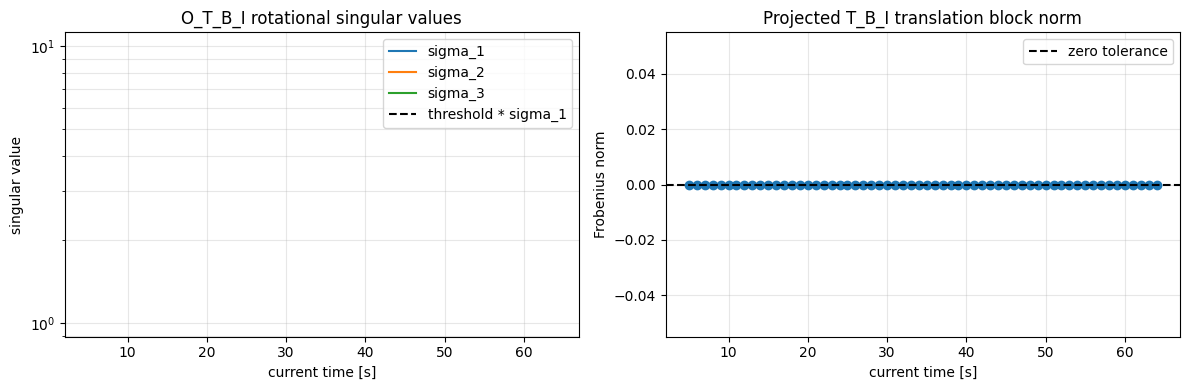

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(imu_rank_df["current_time"], imu_rank_df["sigma_1_rot"], label="sigma_1")
axes[0].semilogy(imu_rank_df["current_time"], imu_rank_df["sigma_2_rot"], label="sigma_2")
axes[0].semilogy(imu_rank_df["current_time"], imu_rank_df["sigma_3_rot"], label="sigma_3")
axes[0].semilogy(imu_rank_df["current_time"], RELATIVE_RANK_THRESHOLD * imu_rank_df["sigma_1_rot"], "k--", label="threshold * sigma_1")
axes[0].set_title("O_T_B_I rotational singular values")
axes[0].set_xlabel("current time [s]")
axes[0].set_ylabel("singular value")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()
axes[1].plot(imu_rank_df["current_time"], imu_rank_df["translation_block_norm"], marker="o")
axes[1].axhline(ABSOLUTE_ZERO_TOLERANCE, color="k", linestyle="--", label="zero tolerance")
axes[1].set_title("Projected T_B_I translation block norm")
axes[1].set_xlabel("current time [s]")
axes[1].set_ylabel("Frobenius norm")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "imu_extrinsic_rank_investigation.png", dpi=160)
plt.show()


## 9. Consistency of C_X_L, J_T_B_L, and O_T_B_L

This section compares LiDAR motion-only `C_X_L`, direct measured `J_T_B_L`, and joint projected `O_T_B_L` using the same rolling windows. The equality `rank(J_T_B_L) == rank(C_X_L)` is conditional on identical LiDAR factor sets, measurement-only rows, no LiDAR priors, nonsingular whitening blocks, nonsingular left-Jacobian/adjoint factors, consistent physical scaling, and the same rank threshold policy.

The mandatory inequality is `rank(O_T_B_L) <= rank(J_T_B_L)`. A problem is indicated by a violation or by selected-window spectra showing ranks that depend on tiny retained singular values.


In [30]:
lidar_rows = []
for record in window_records:
    result = record["target_results"].get("T_B_L")
    if result is None or record["lidar_motion"] is None:
        continue
    J_T_B_L = result["J_X_physical"]
    O_T_B_L = result["O_X_filtered"]
    C_X_L = to_dense(record["lidar_motion"].C_X_L_raw)
    C_rejection = reject_and_normalize_columns_dense(
        C_X_L,
        absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
        relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
    )
    C_filtered = filtered_physical_matrix(C_X_L, C_rejection)
    stats_C = matrix_stats(C_filtered)
    stats_J = matrix_stats(J_T_B_L)
    stats_O = matrix_stats(O_T_B_L)
    assert stats_O["effective_rank"] <= stats_J["effective_rank"]
    lidar_rows.append({
        "current_time": record["current_time"],
        "rank_C_X_L": stats_C["effective_rank"],
        "rank_J_T_B_L": stats_J["effective_rank"],
        "rank_O_T_B_L": stats_O["effective_rank"],
        "nullity_C_X_L": C_filtered.shape[1] - stats_C["effective_rank"],
        "nullity_J_T_B_L": J_T_B_L.shape[1] - stats_J["effective_rank"],
        "nullity_O_T_B_L": O_T_B_L.shape[1] - stats_O["effective_rank"],
        "sigma_3_over_sigma_1_C": stats_C["singular_values"][2] / stats_C["singular_values"][0] if len(stats_C["singular_values"]) >= 3 and stats_C["singular_values"][0] > 0 else np.nan,
        "sigma_5_over_sigma_1_C": stats_C["singular_values"][4] / stats_C["singular_values"][0] if len(stats_C["singular_values"]) >= 5 and stats_C["singular_values"][0] > 0 else np.nan,
        "C_column_norms": C_rejection.original_column_norms.tolist(),
        "C_zero_mask": json.dumps(C_rejection.zero_column_mask.astype(bool).tolist()),
        "J_singular_values": stats_J["singular_values"].tolist(),
        "O_singular_values": stats_O["singular_values"].tolist(),
    })
lidar_consistency_df = pd.DataFrame(lidar_rows)
display(lidar_consistency_df.head())
for debug_time in SELECTED_DEBUG_TIMES:
    nearest = min(window_records, key=lambda r: abs(r["current_time"] - debug_time))
    print(f"\\nselected window t={nearest['current_time']:.1f}s")
    matrices = {
        "C_X_L": to_dense(nearest["lidar_motion"].C_X_L_raw),
        "J_T_B_L": nearest["target_results"]["T_B_L"]["J_X_physical"],
        "O_T_B_L": nearest["target_results"]["T_B_L"]["O_X_filtered"],
    }
    for matrix_name, matrix in matrices.items():
        rejection = reject_and_normalize_columns_dense(
            matrix,
            absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
            relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
        )
        stats = matrix_stats(filtered_physical_matrix(matrix, rejection))
        print(matrix_name, {
            "shape": matrix.shape,
            "rank": stats["effective_rank"],
            "singular_values": stats["singular_values"],
            "normalized_singular_values": stats["normalized_singular_values"],
            "column_norms": rejection.original_column_norms,
            "zero_mask": rejection.zero_column_mask,
        })


,current_time,rank_C_X_L,rank_J_T_B_L,rank_O_T_B_L,nullity_C_X_L,nullity_J_T_B_L,nullity_O_T_B_L,sigma_3_over_sigma_1_C,sigma_5_over_sigma_1_C,C_column_norms,C_zero_mask,J_singular_values,O_singular_values
0,5.0,2,2,0,4,4,6,0.000000,0.000000,"[0.0, 0.9797958971132712, 0.9797958971132712, ...","[true, false, false, true, true, true]","[48.989940374558145, 48.98989231275155, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,6.0,2,2,0,4,4,6,0.000000,0.000000,"[0.0, 0.9999999999999999, 0.9999999999999999, ...","[true, false, false, true, true, true]","[50.000143290262095, 50.00009578332986, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,7.0,2,2,0,4,4,6,0.000000,0.000000,"[0.0, 0.9999999999999998, 0.9999999999999998, ...","[true, false, false, true, true, true]","[50.000113739799936, 50.00008597186557, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,8.0,2,2,0,4,4,6,0.000000,0.000000,"[0.0, 0.9999999999999999, 0.9999999999999999, ...","[true, false, false, true, true, true]","[50.00010883744316, 50.00007982403033, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,9.0,5,5,0,1,1,6,0.472567,0.472567,"[0.4674654989001259, 0.9892037164618537, 0.871...","[false, false, false, false, false, true]","[103.20193077992081, 93.91026053560199, 43.589...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


\nselected window t=5.0s
C_X_L {'shape': (144, 6), 'rank': 2, 'singular_values': array([0.9797959, 0.9797959, 0.       , 0.       , 0.       , 0.       ]), 'normalized_singular_values': array([1., 1., 0., 0., 0., 0.]), 'column_norms': array([0.       , 0.9797959, 0.9797959, 0.       , 0.       , 0.       ]), 'zero_mask': array([ True, False, False,  True,  True,  True])}
J_T_B_L {'shape': (216, 6), 'rank': 2, 'singular_values': array([48.98994037, 48.98989231,  0.        ,  0.        ,  0.        ,
        0.        ]), 'normalized_singular_values': array([1.        , 0.99999902, 0.        , 0.        , 0.        ,
       0.        ]), 'column_norms': array([ 0.        , 48.98990767, 48.98992502,  0.        ,  0.        ,
        0.        ]), 'zero_mask': array([ True, False, False,  True,  True,  True])}
O_T_B_L {'shape': (216, 6), 'rank': 0, 'singular_values': array([0., 0., 0., 0., 0., 0.]), 'normalized_singular_values': array([0., 0., 0., 0., 0., 0.]), 'column_norms': array([0., 0

## 10. Annotated Selected-Window Matrices

For selected debug times, heatmaps show `J_T_B_I`, `O_T_B_I`, `C_X_L`, `J_T_B_L`, and `O_T_B_L`. Color limits are fixed across selected windows for each matrix family. Each title reports shape, Frobenius norm, effective rank, `sigma_min_retained`, `sigma_3/sigma_1`, and rejected columns.

The text panel lists raw singular values, normalized singular values, original column norms, zero threshold, and zero-column mask. A problem is indicated by independently autoscaled plots hiding weak modes or by rejected columns becoming nonzero.


selected current times: [5.0, 12.0, 23.0, 38.0, 54.0]


/tmp/ipykernel_3358707/2962157418.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


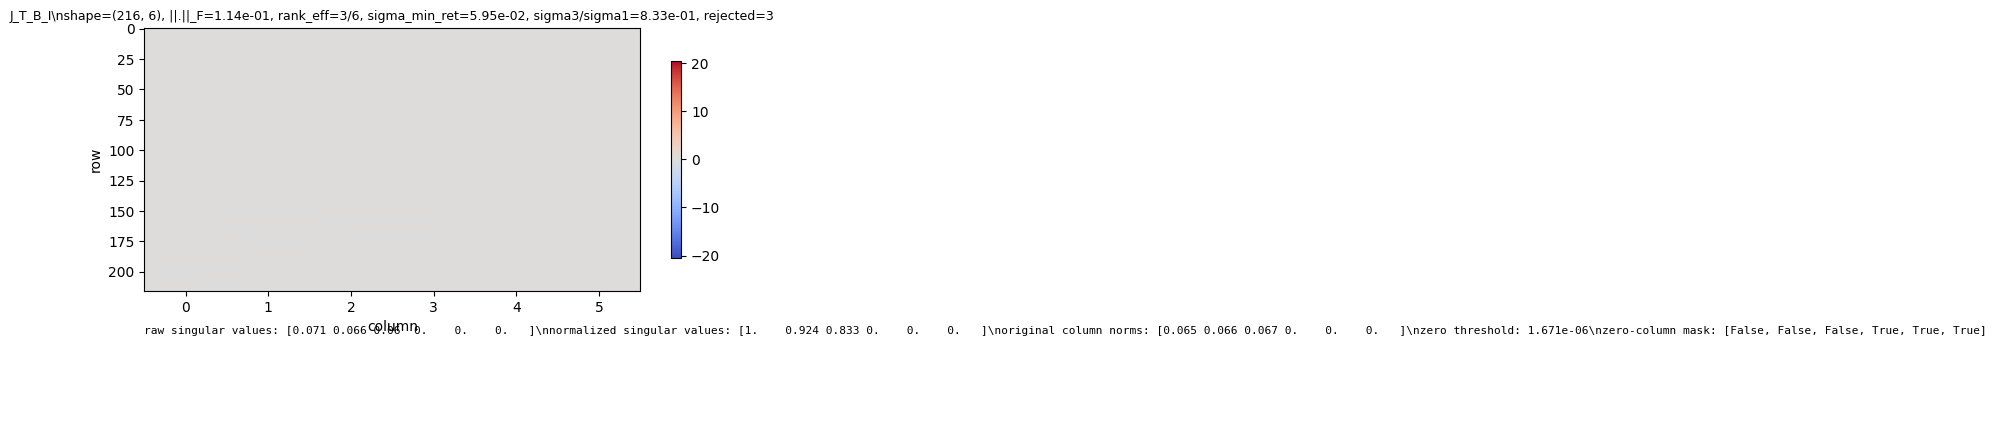

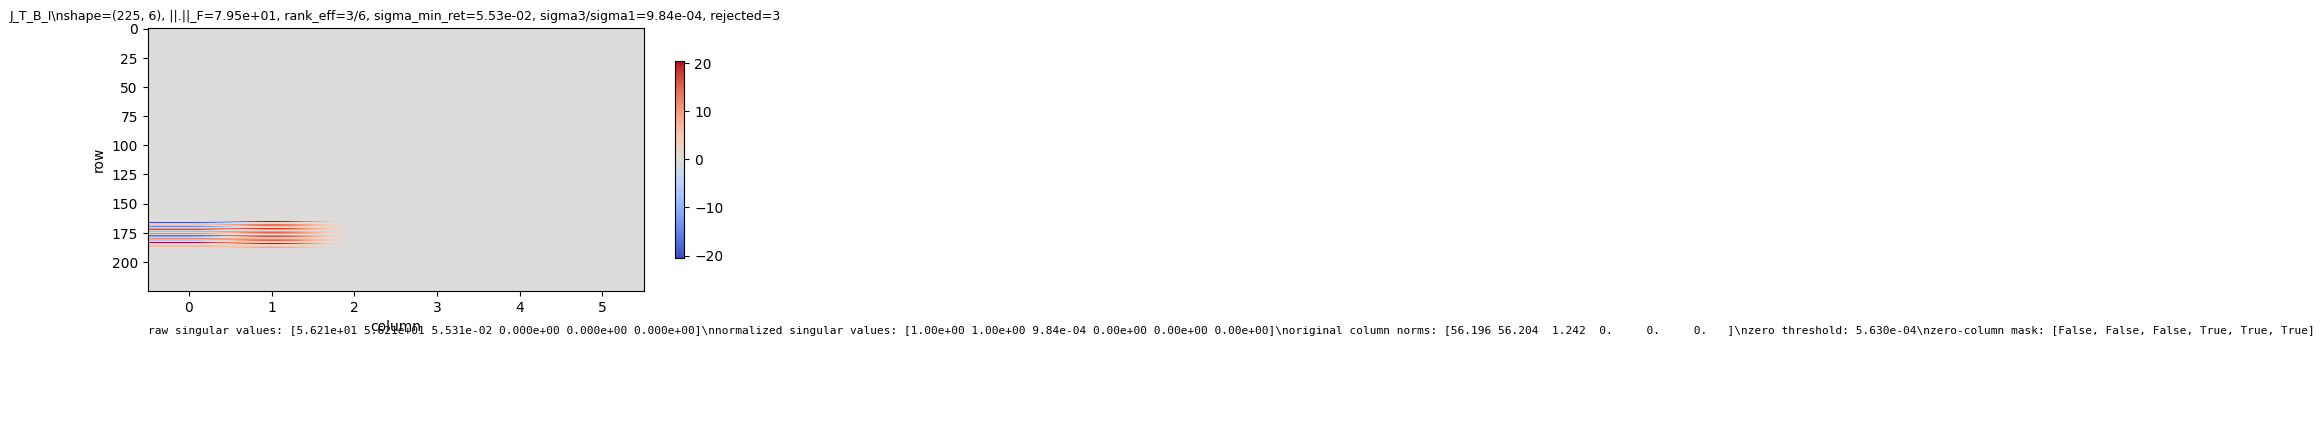

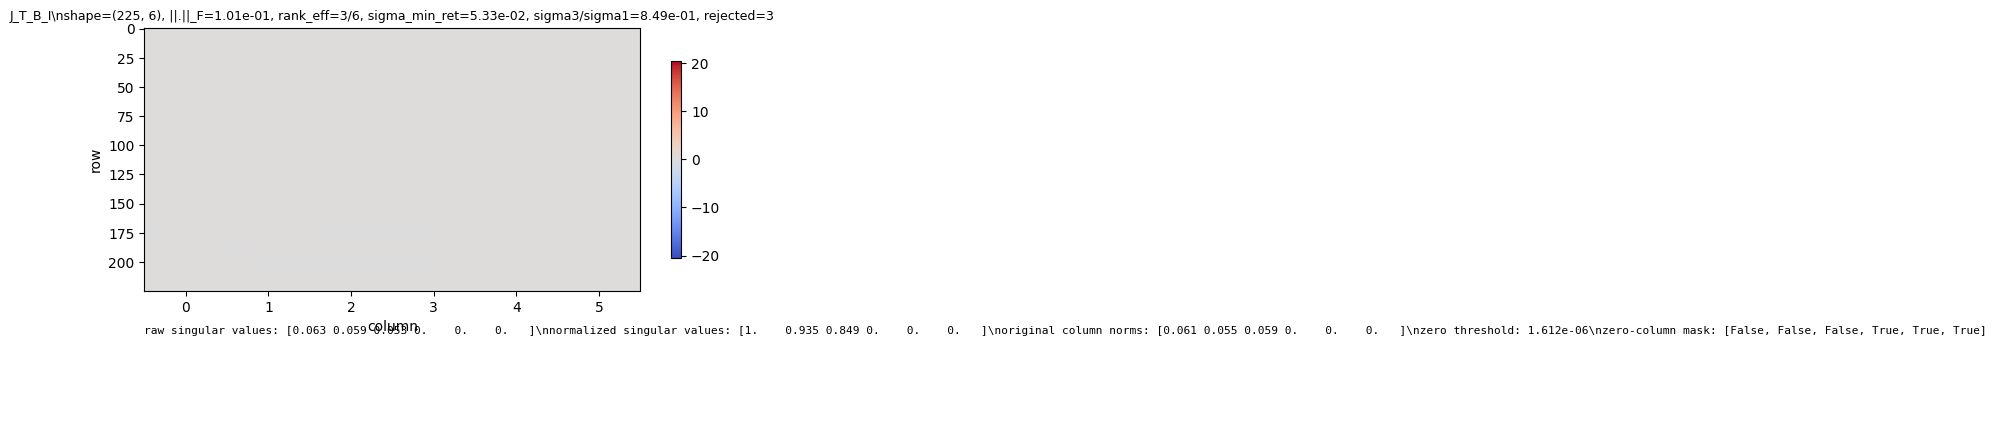

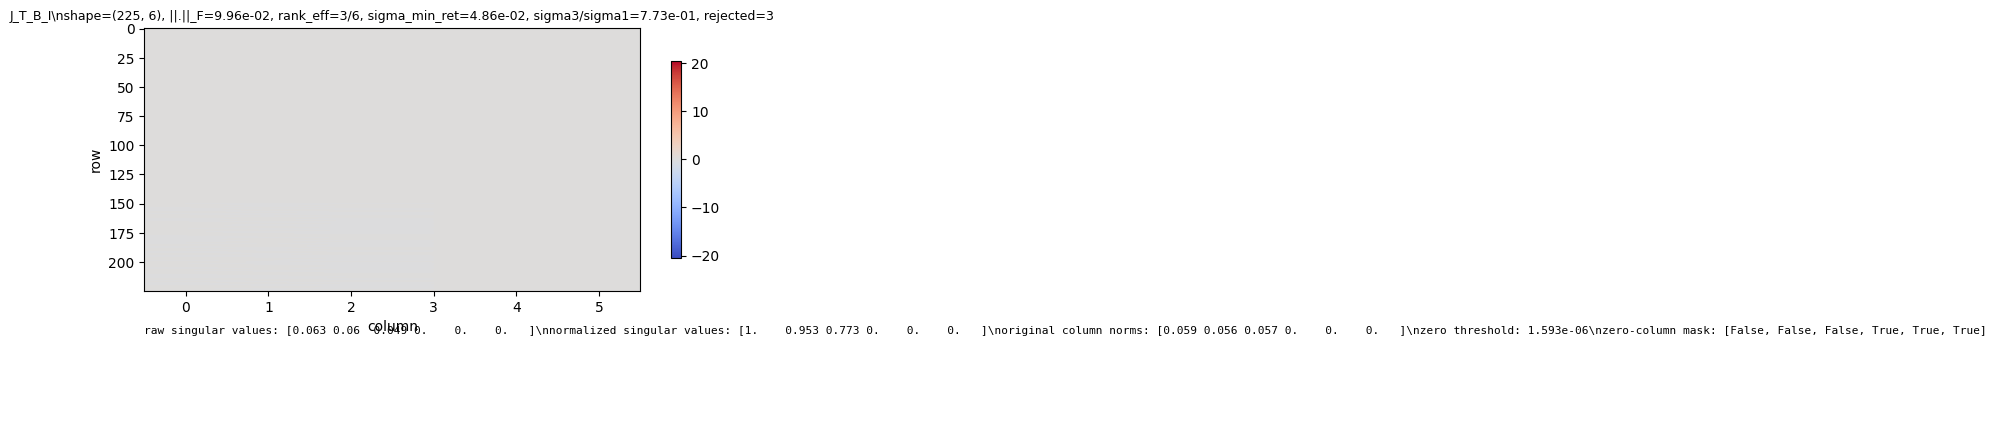

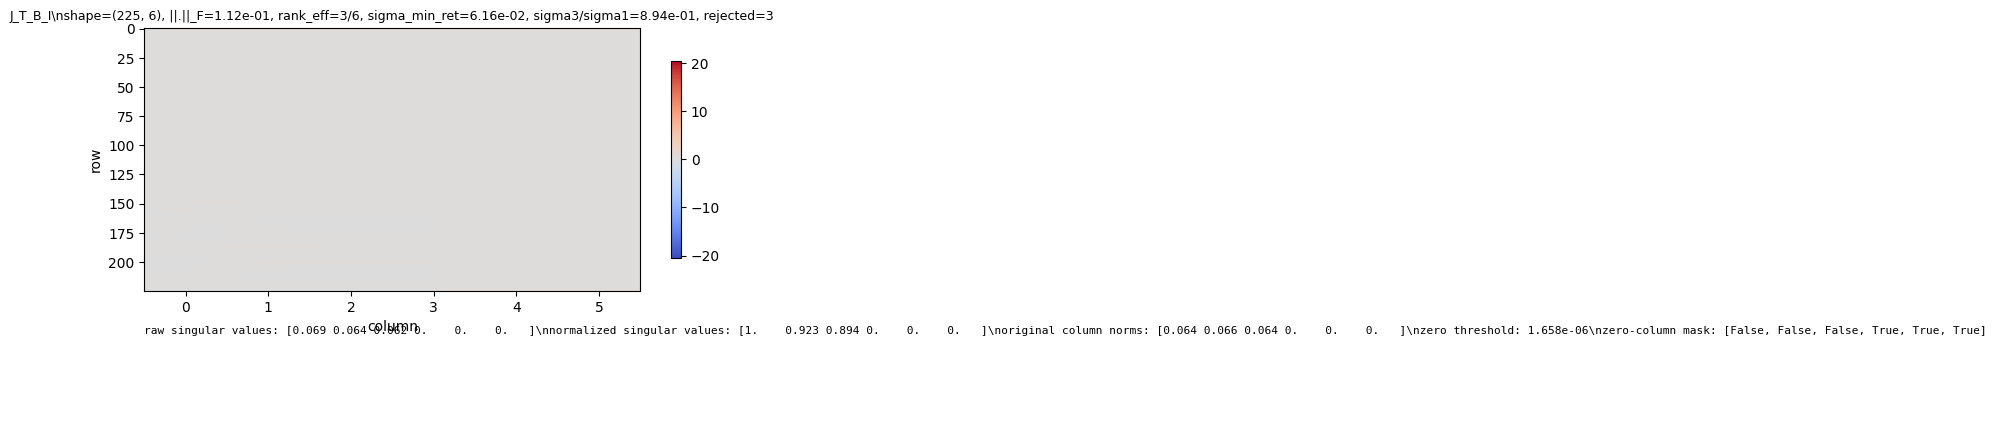

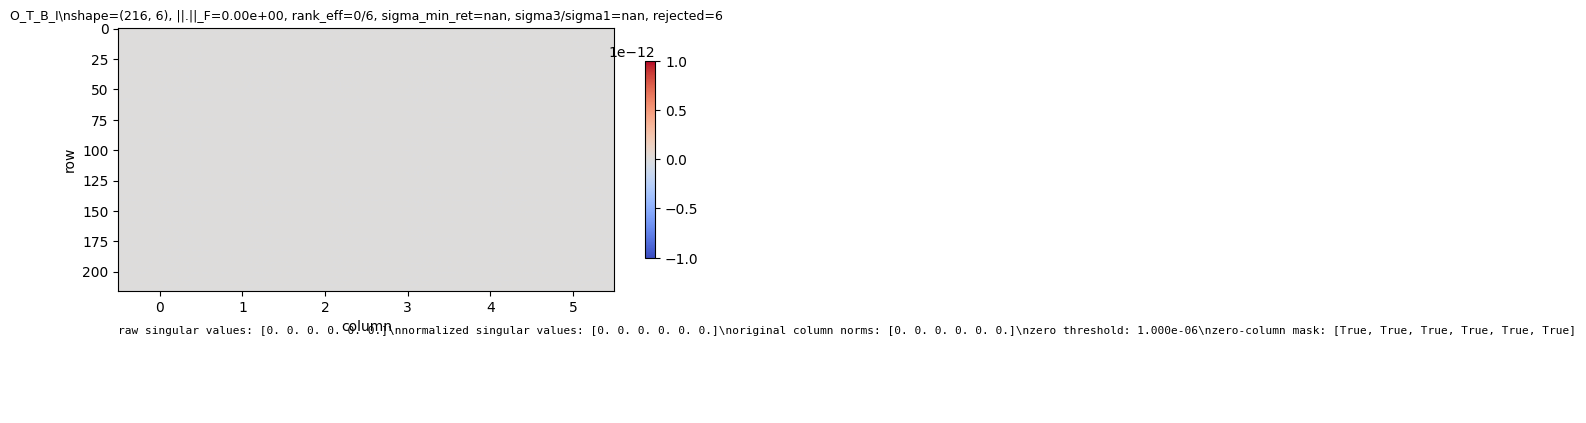

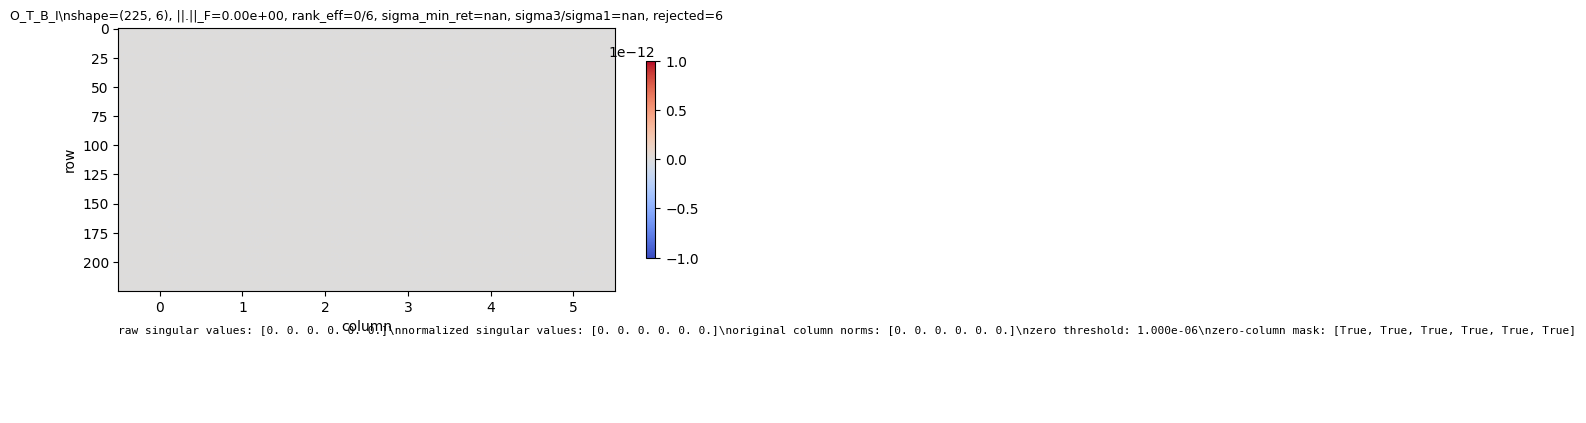

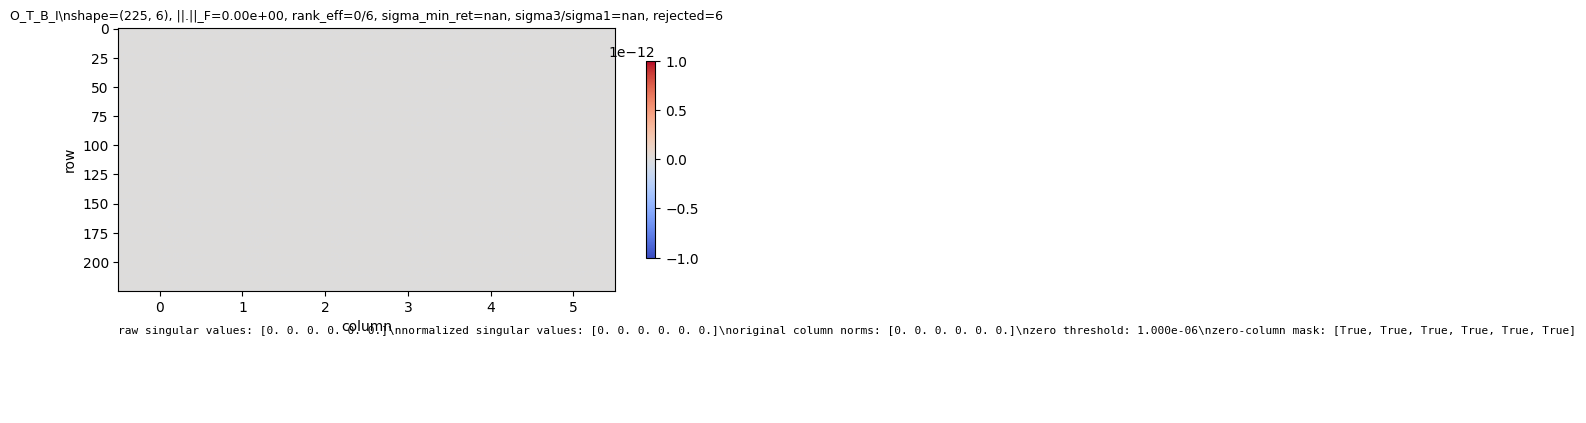

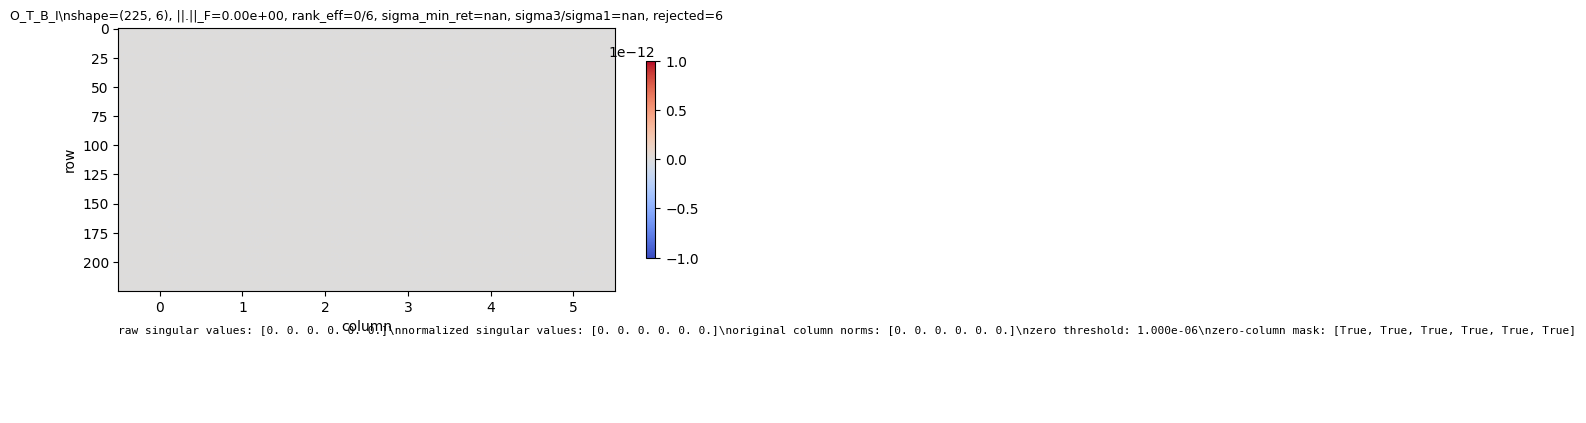

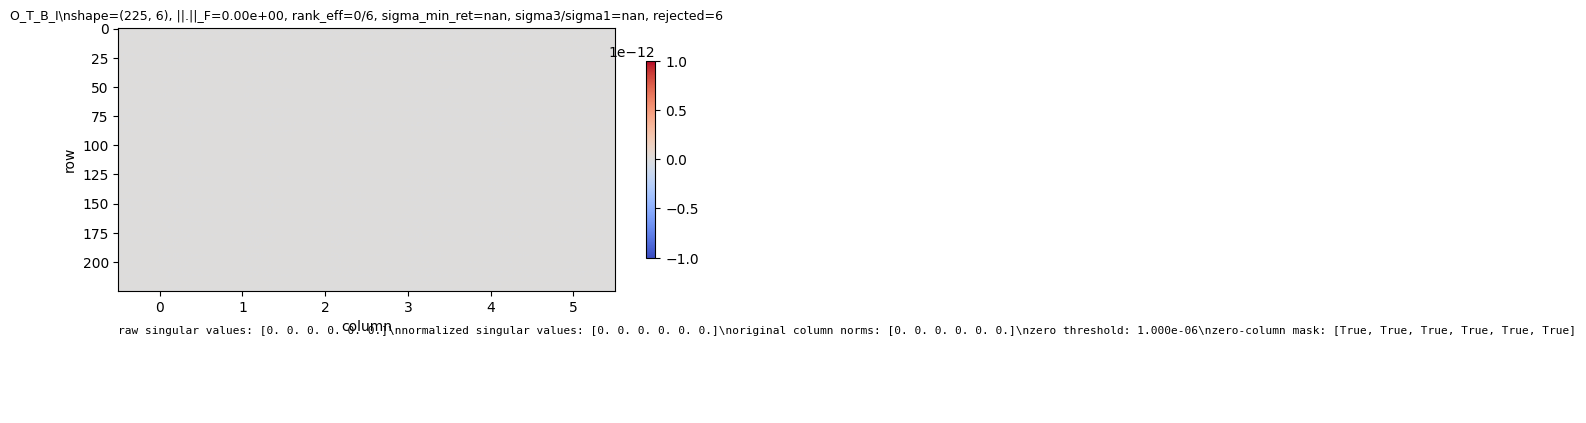

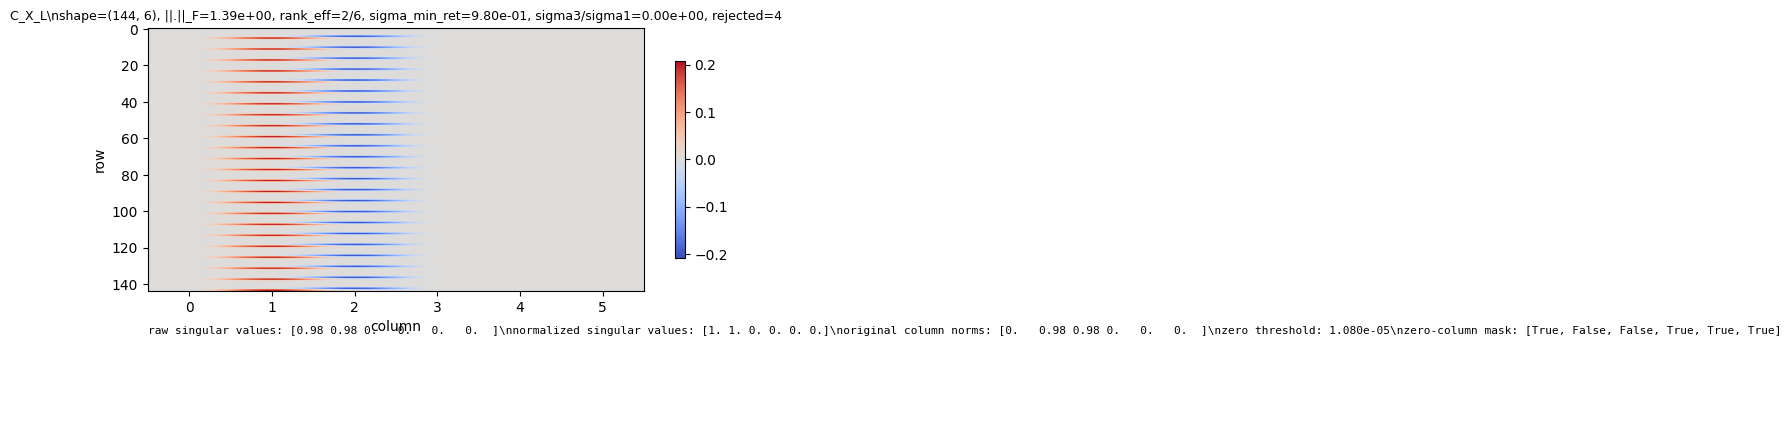

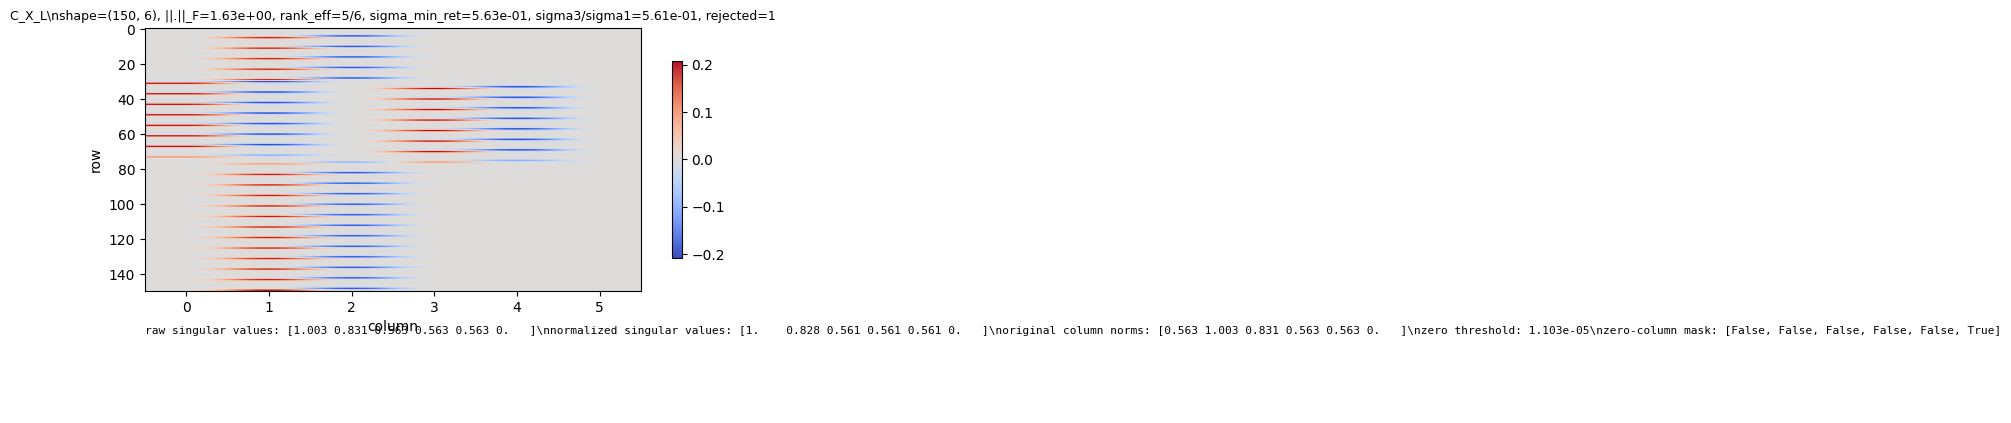

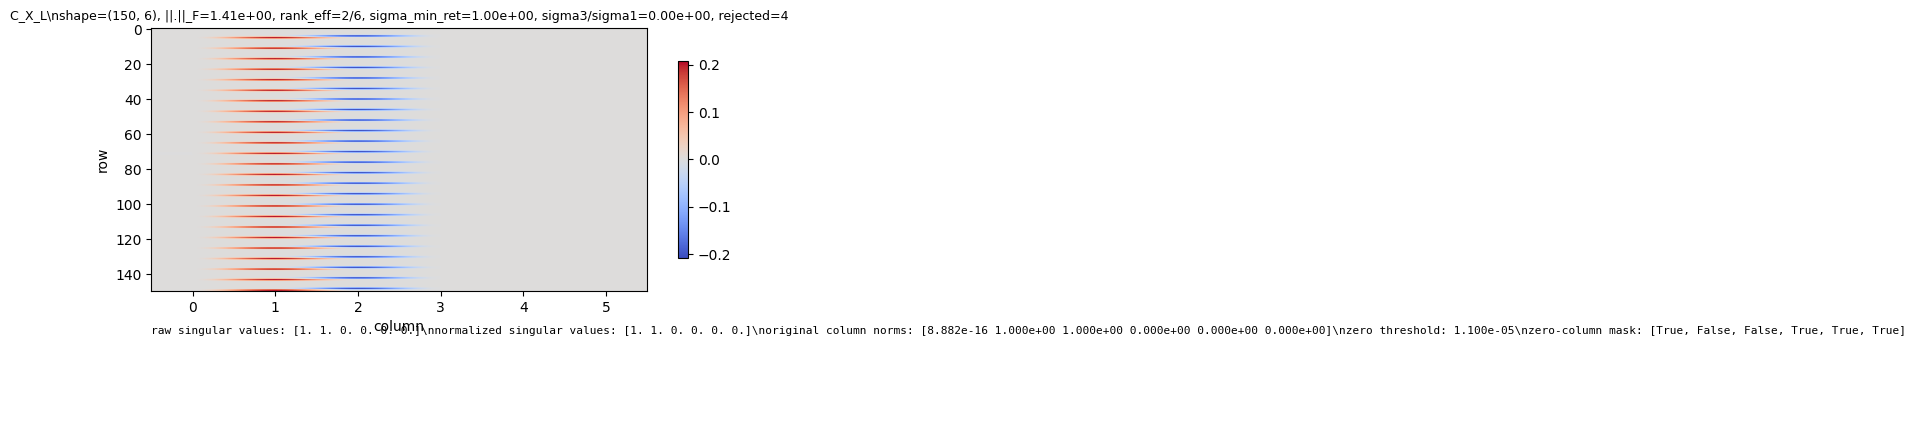

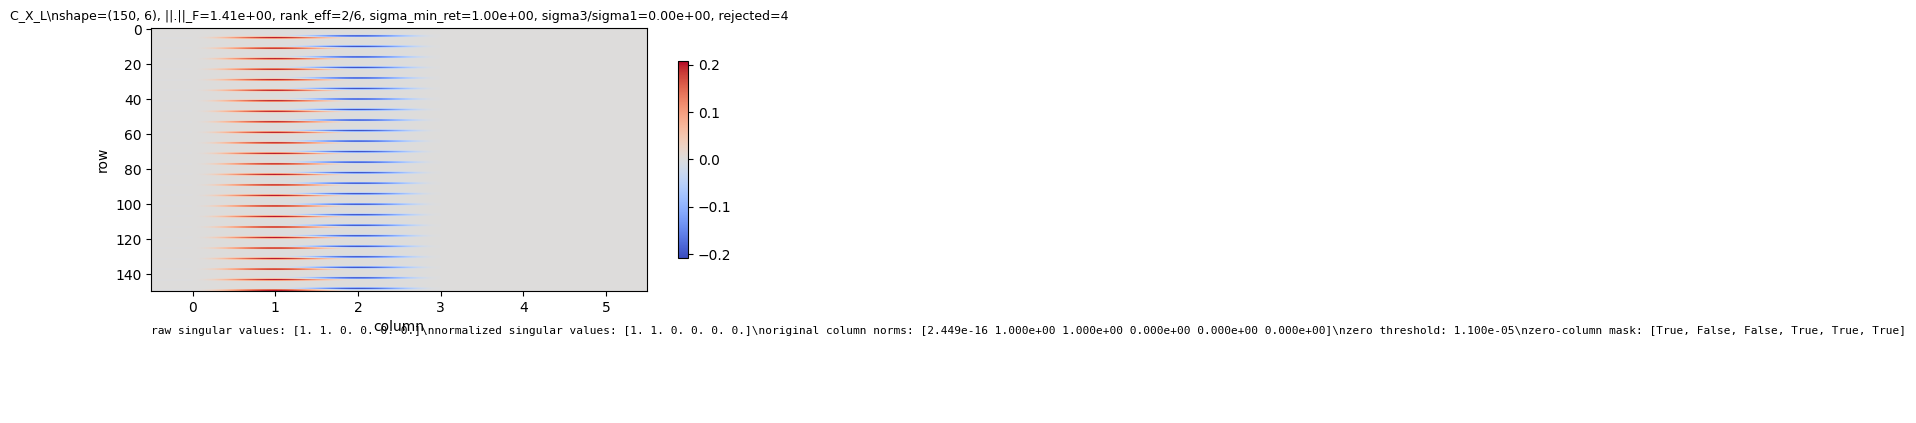

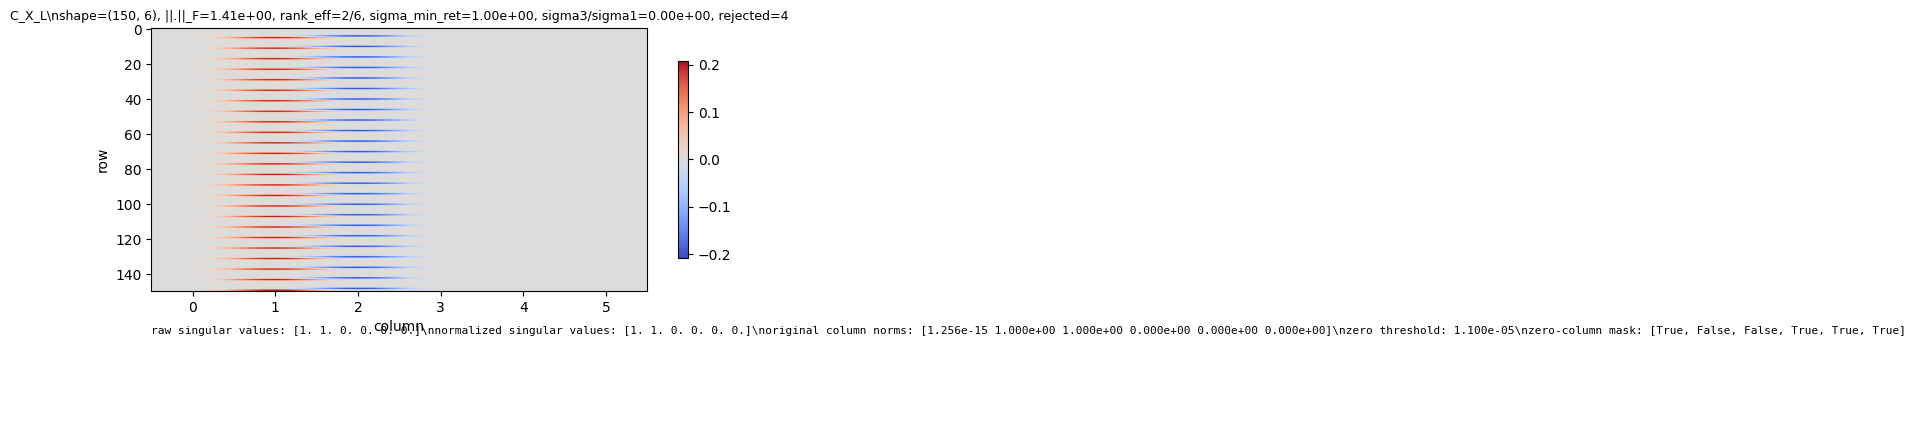

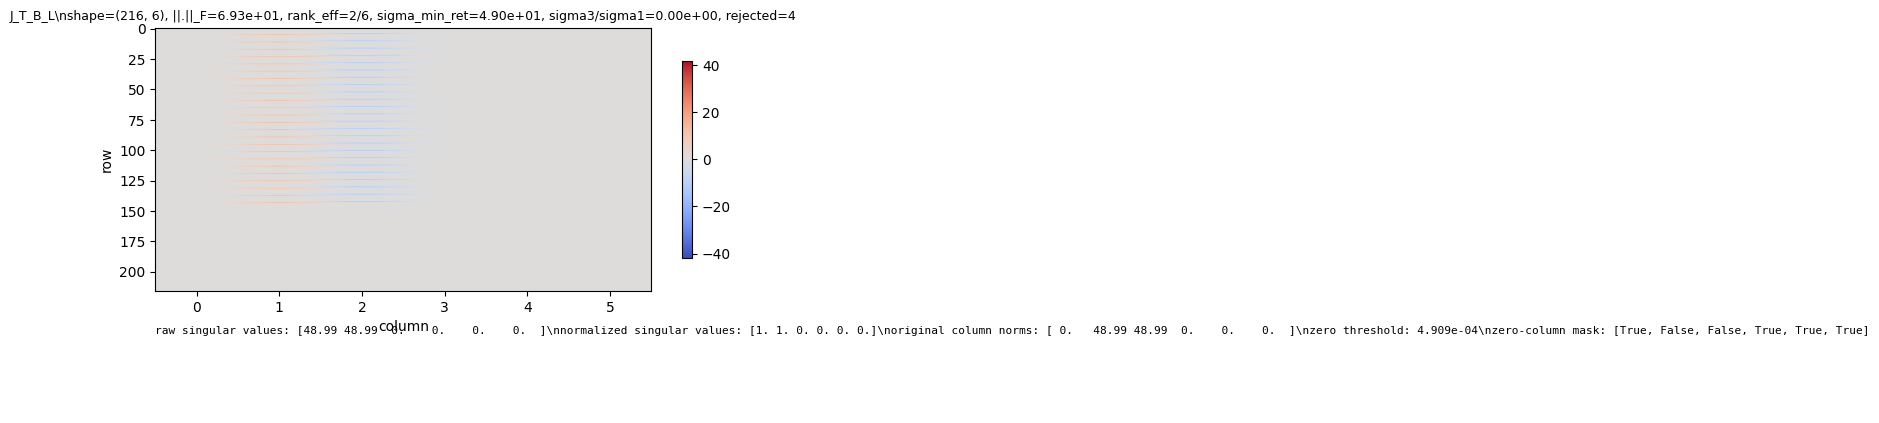

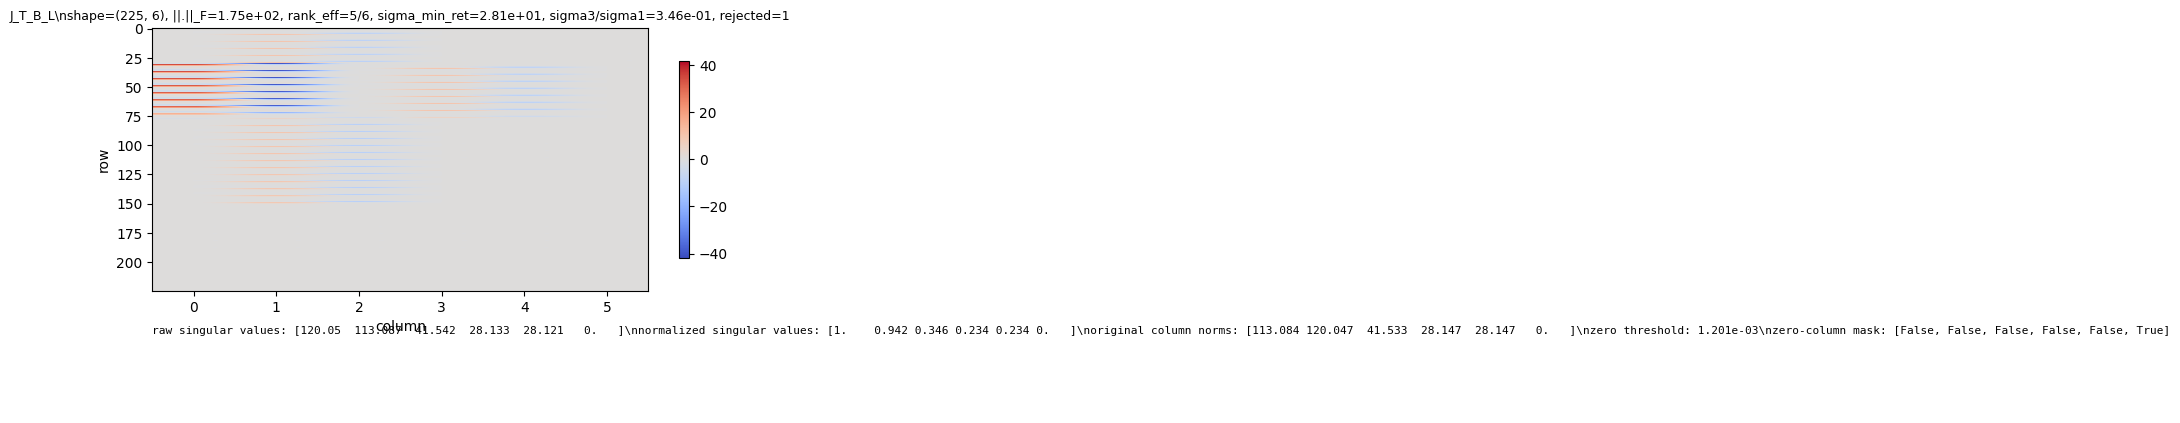

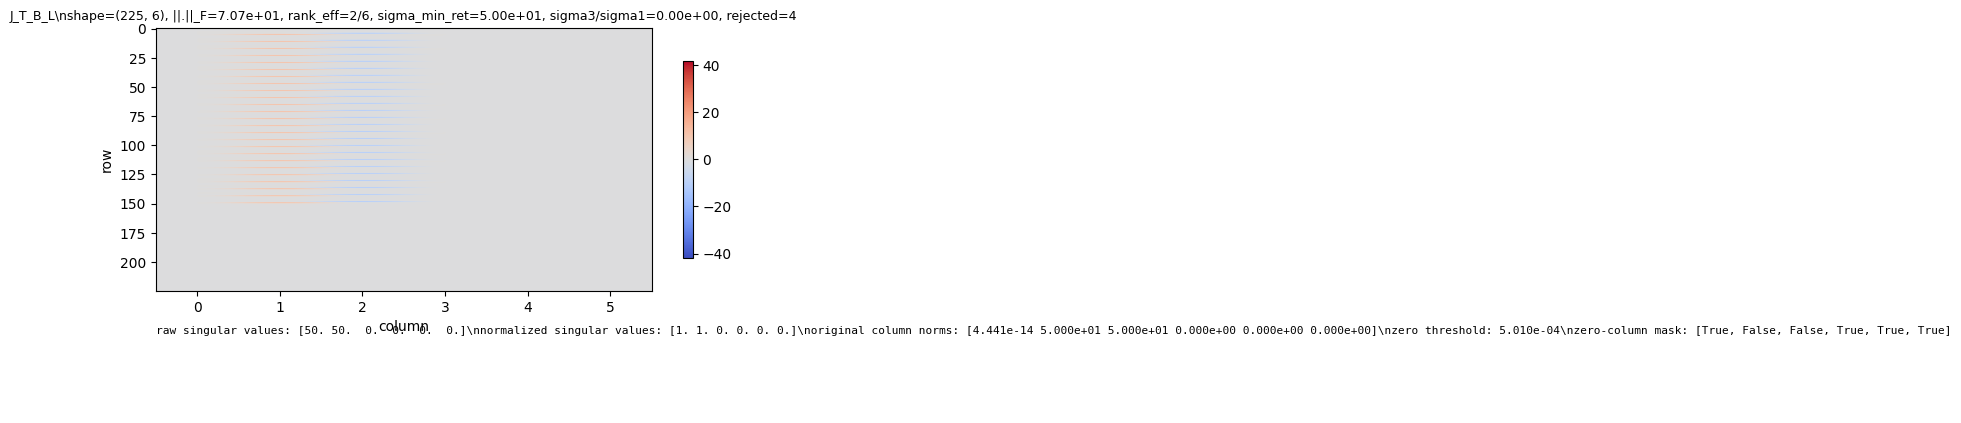

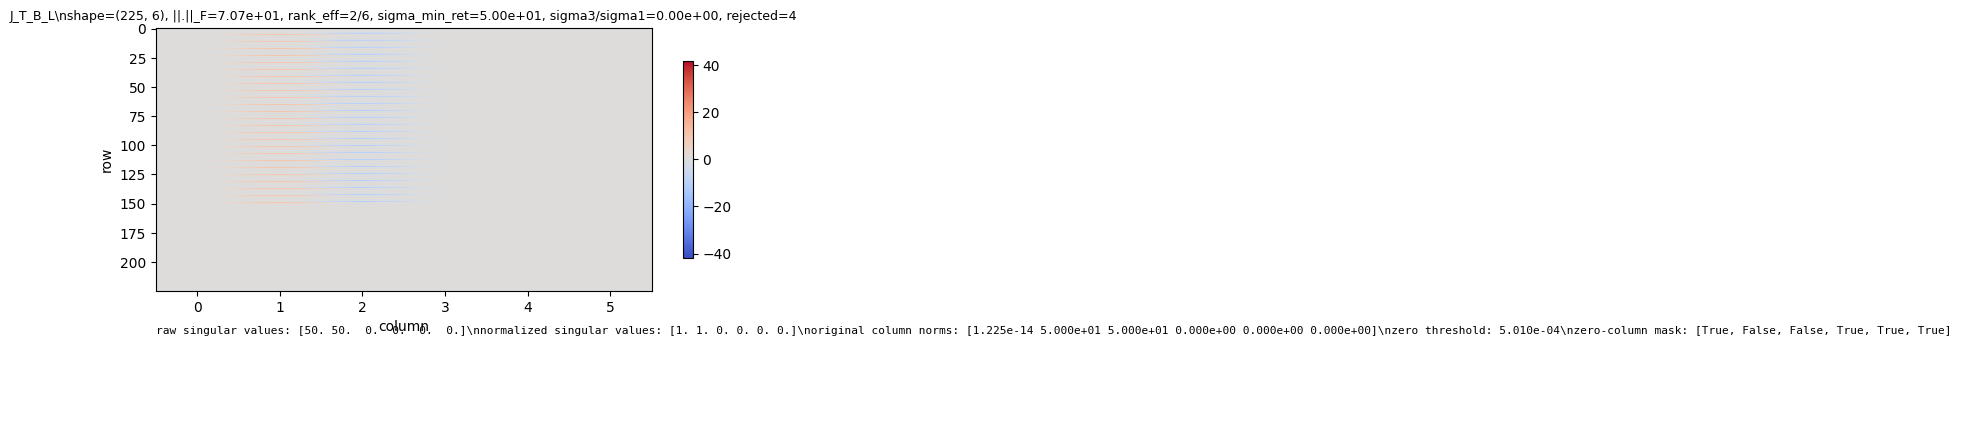

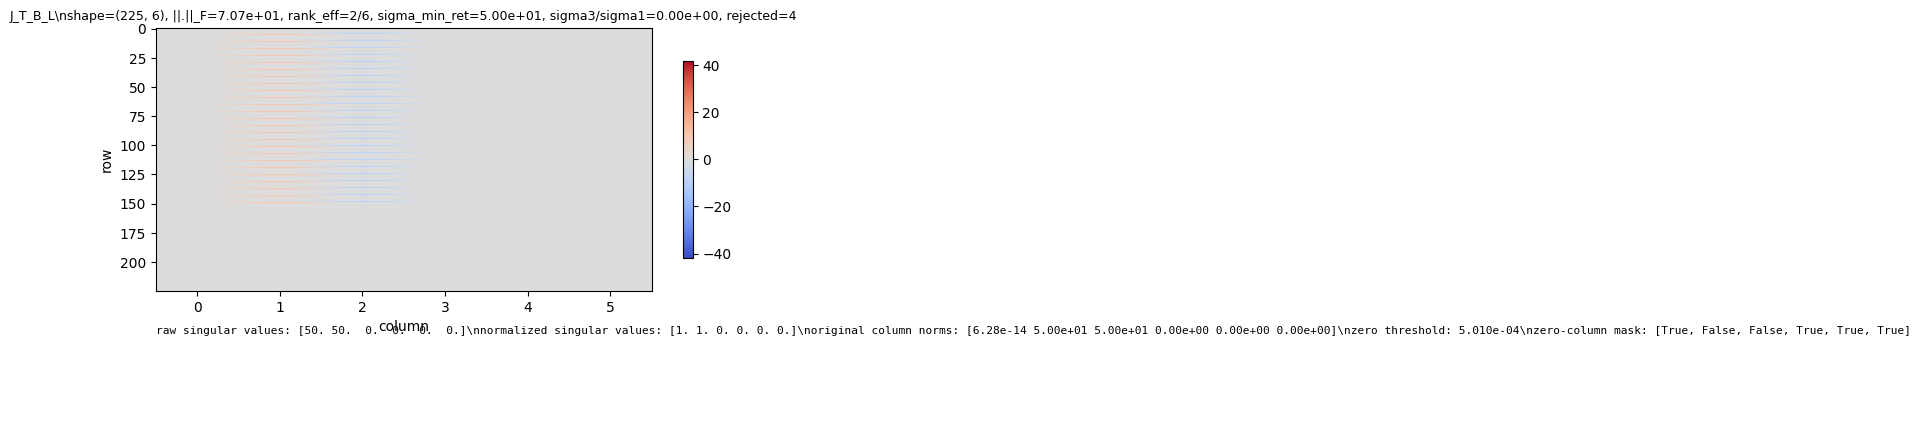

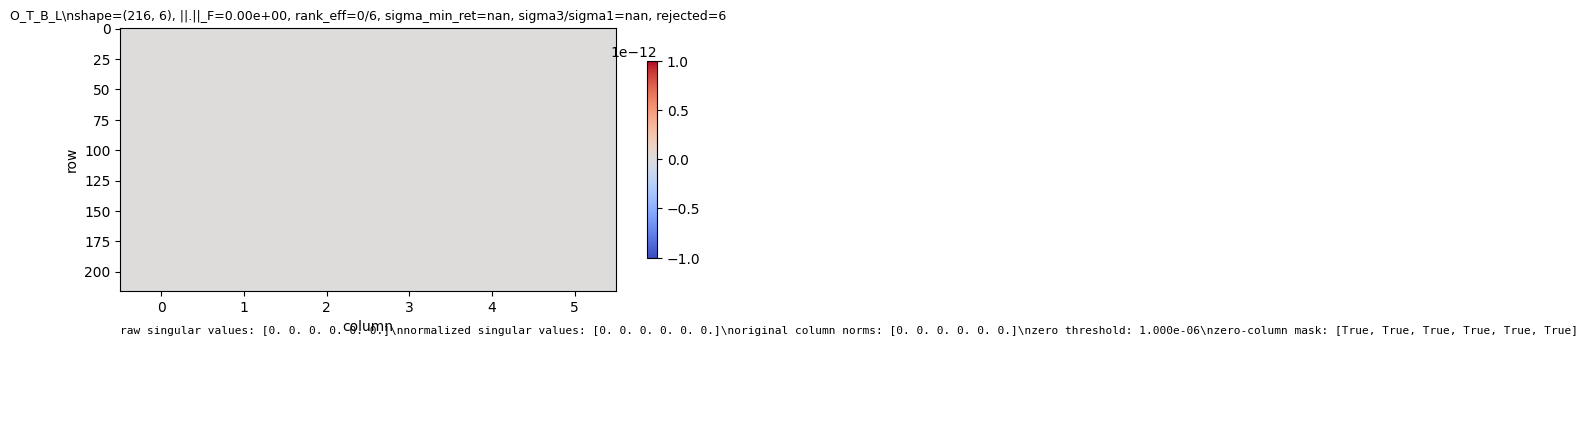

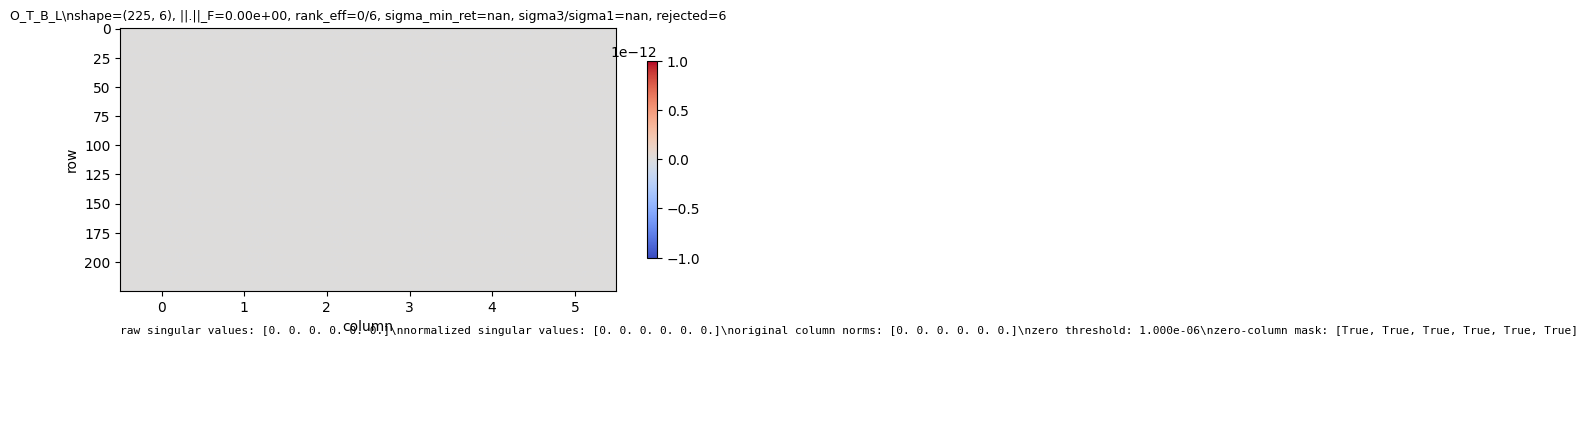

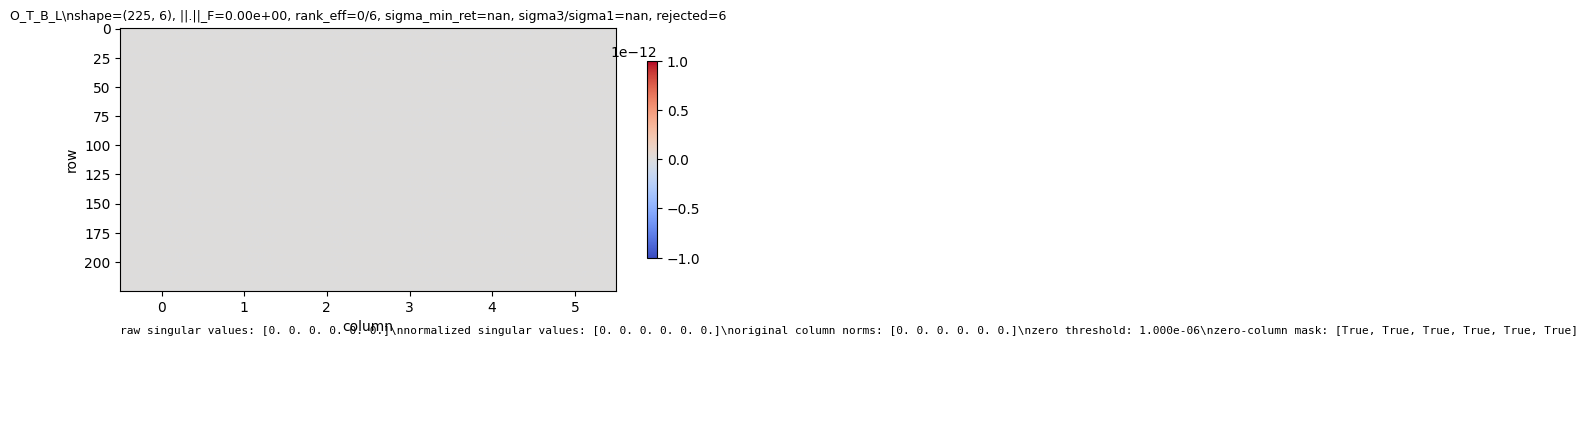

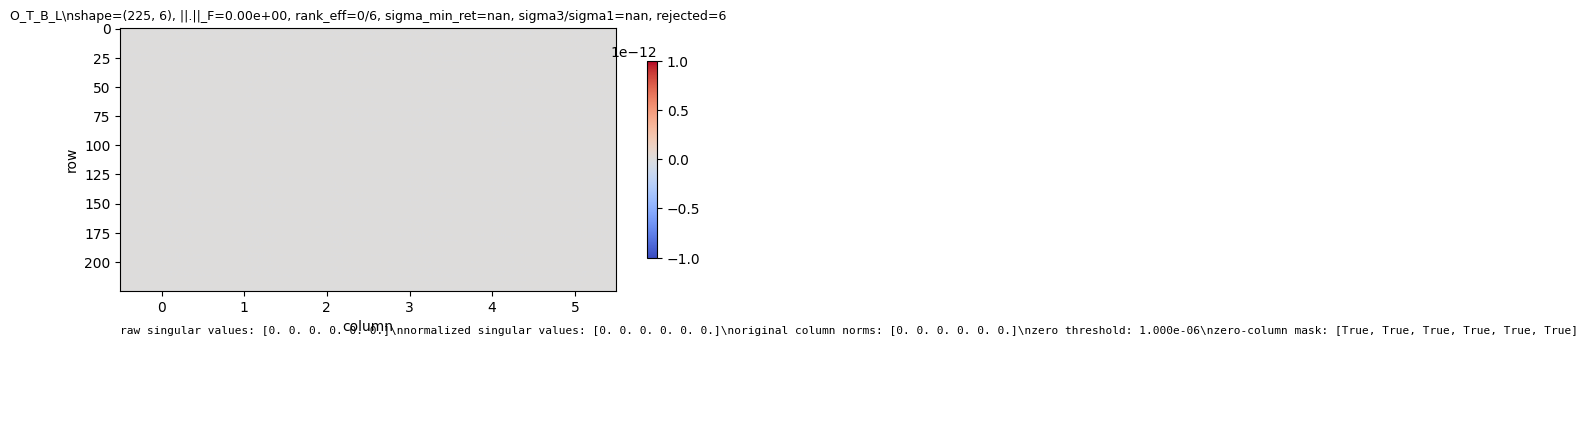

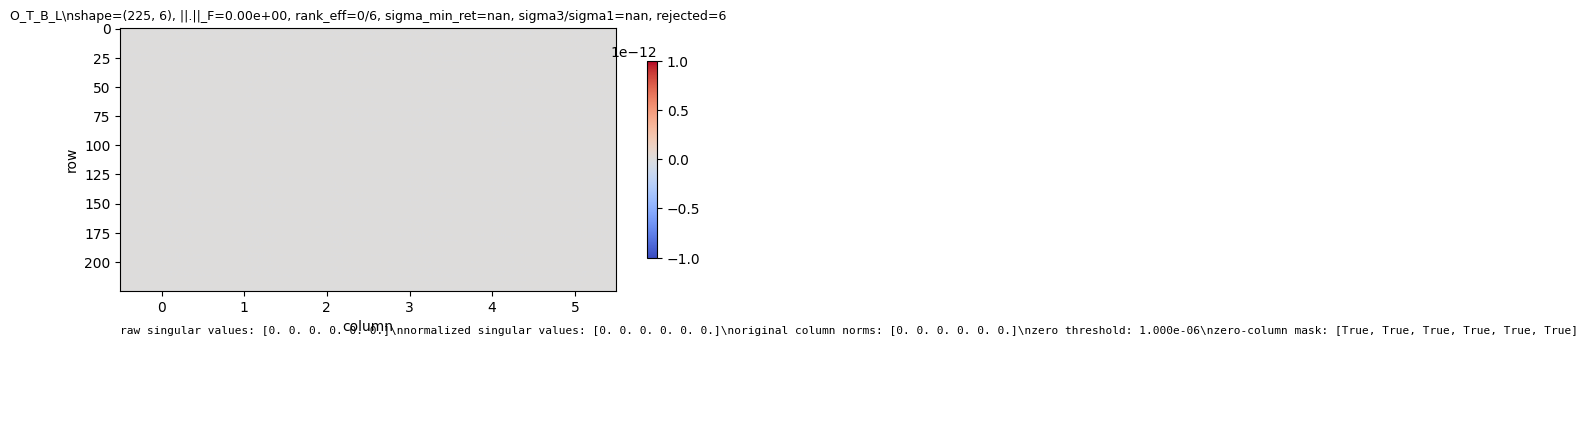

In [31]:
selected_records = [min(window_records, key=lambda r: abs(r["current_time"] - time_value)) for time_value in SELECTED_DEBUG_TIMES]
selected_times = [record["current_time"] for record in selected_records]
print("selected current times:", selected_times)
matrix_families = {"J_T_B_I": [], "O_T_B_I": [], "C_X_L": [], "J_T_B_L": [], "O_T_B_L": []}
for record in selected_records:
    matrix_families["J_T_B_I"].append(record["target_results"]["T_B_I"]["J_X_physical"])
    matrix_families["O_T_B_I"].append(record["target_results"]["T_B_I"]["O_X_filtered"])
    matrix_families["C_X_L"].append(to_dense(record["lidar_motion"].C_X_L_raw) if record["lidar_motion"] else np.zeros((0, 6)))
    matrix_families["J_T_B_L"].append(record["target_results"]["T_B_L"]["J_X_physical"])
    matrix_families["O_T_B_L"].append(record["target_results"]["T_B_L"]["O_X_filtered"])
color_limits = {
    name: max(max((float(np.max(np.abs(matrix))) for matrix in matrices if matrix.size), default=1.0), 1e-12)
    for name, matrices in matrix_families.items()
}

def annotated_title(name: str, matrix: np.ndarray, rejection) -> str:
    stats = matrix_stats(filtered_physical_matrix(matrix, rejection))
    singular = stats["singular_values"]
    sigma_ratio = singular[2] / singular[0] if len(singular) >= 3 and singular[0] > 0 else np.nan
    retained = singular[stats["retained_mask"]]
    sigma_min_retained = retained[-1] if retained.size else np.nan
    return (
        f"{name}\\nshape={matrix.shape}, ||.||_F={stats['frobenius_norm']:.2e}, "
        f"rank_eff={stats['effective_rank']}/{matrix.shape[1] if matrix.ndim == 2 else 0}, "
        f"sigma_min_ret={sigma_min_retained:.2e}, sigma3/sigma1={sigma_ratio:.2e}, "
        f"rejected={int(np.sum(rejection.zero_column_mask))}"
    )

for family_name, matrices in matrix_families.items():
    limit = color_limits[family_name]
    for record, matrix in zip(selected_records, matrices):
        rejection = reject_and_normalize_columns_dense(
            matrix,
            absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
            relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
        )
        stats = matrix_stats(filtered_physical_matrix(matrix, rejection))
        fig, axes = plt.subplots(2, 1, figsize=(8, 5), gridspec_kw={"height_ratios": [3, 1]})
        im = axes[0].imshow(matrix, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
        axes[0].set_title(annotated_title(family_name, matrix, rejection), fontsize=9)
        axes[0].set_xlabel("column")
        axes[0].set_ylabel("row")
        fig.colorbar(im, ax=axes[0], shrink=0.75)
        axes[1].axis("off")
        panel_text = (
            f"raw singular values: {np.array2string(stats['singular_values'], precision=3)}\\n"
            f"normalized singular values: {np.array2string(stats['normalized_singular_values'], precision=3)}\\n"
            f"original column norms: {np.array2string(rejection.original_column_norms, precision=3)}\\n"
            f"zero threshold: {rejection.zero_threshold:.3e}\\n"
            f"zero-column mask: {rejection.zero_column_mask.tolist()}"
        )
        axes[1].text(0.0, 1.0, panel_text, family="monospace", fontsize=8, va="top")
        fig.tight_layout()
        figure_path = MATRIX_OUTPUT_DIRECTORY / f"{family_name}_t_{record['current_time']:.1f}.png"
        fig.savefig(figure_path, dpi=160)
        plt.show()
        plt.close(fig)


## 11. Information Strength and Uncertainty

This section uses unnormalized, whitened, physically scaled `O_X_filtered`. For multidimensional targets, singular values give information eigenvalues `lambda_i = sigma_i^2`, total information, retained-direction condition number, and observable-subspace standard-deviation bounds `1/sigma_i`.

A low condition number does not imply strong observability. A nearly zero matrix can have condition number one inside its tiny retained subspace.


/tmp/ipykernel_3358707/1610766486.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, 0].semilogy(subset["current_time"], subset["sigma_min_retained"].replace(0.0, np.nan), marker="o", label=variable_name)


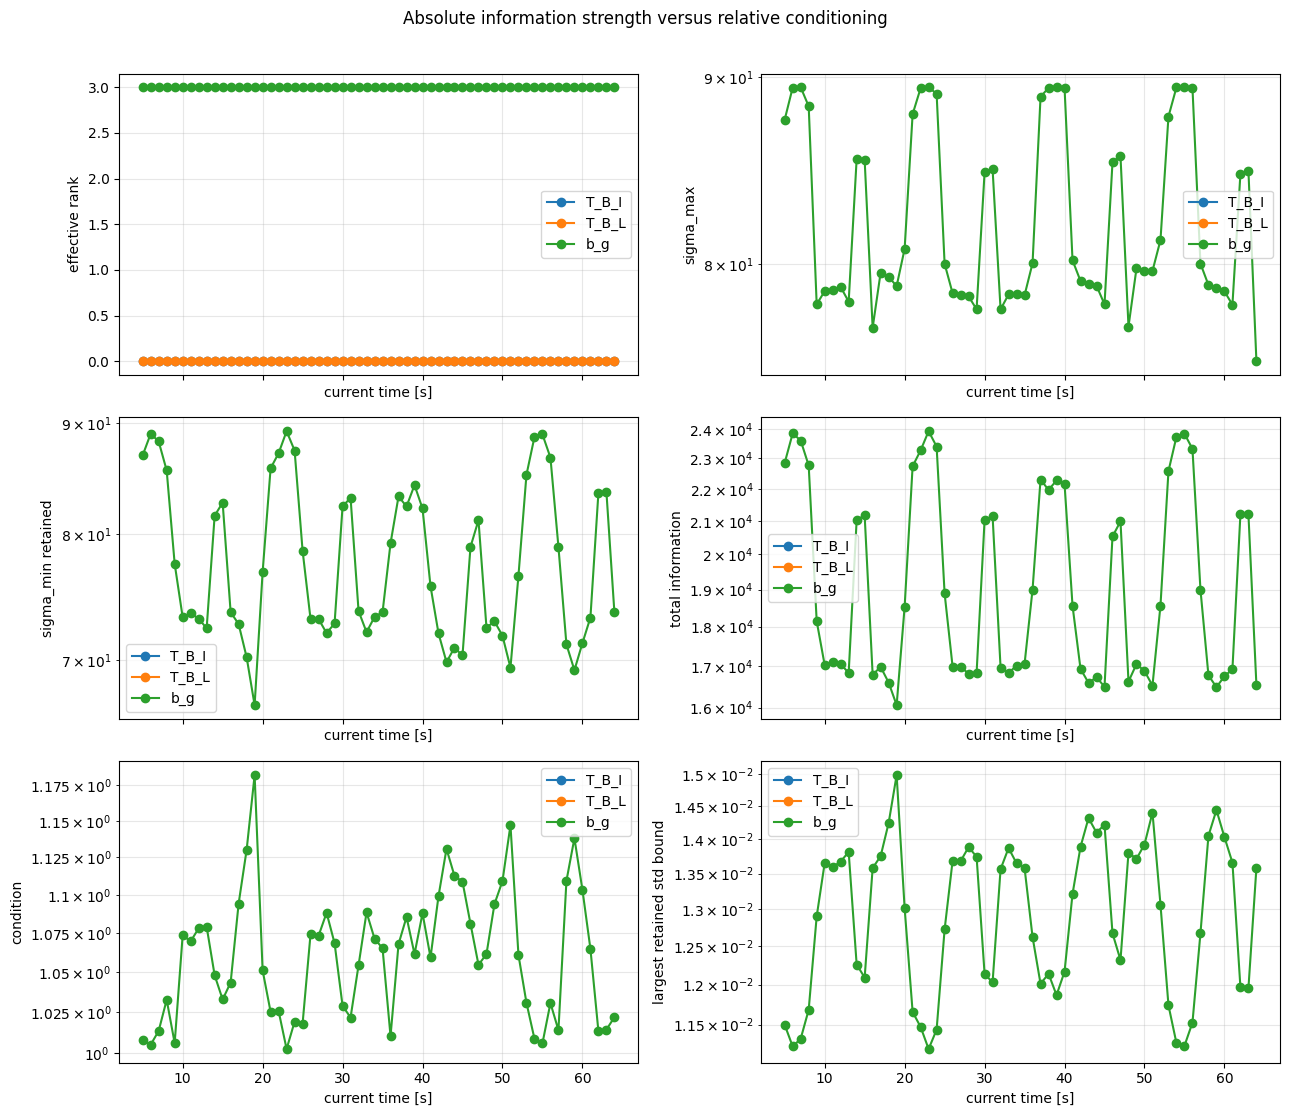

In [32]:
multidim_targets = ["T_B_I", "T_B_L", "b_g"]
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
for variable_name in multidim_targets:
    subset = window_summary_df[window_summary_df["target_name"] == variable_name]
    axes[0, 0].plot(subset["current_time"], subset["effective_rank_O_X"], marker="o", label=variable_name)
    axes[0, 1].semilogy(subset["current_time"], subset["sigma_max"], marker="o", label=variable_name)
    axes[1, 0].semilogy(subset["current_time"], subset["sigma_min_retained"].replace(0.0, np.nan), marker="o", label=variable_name)
    axes[1, 1].semilogy(subset["current_time"], subset["total_information"].replace(0.0, np.nan), marker="o", label=variable_name)
    axes[2, 0].semilogy(subset["current_time"], subset["effective_condition_number"].replace(np.inf, np.nan), marker="o", label=variable_name)
    axes[2, 1].semilogy(subset["current_time"], subset["maximum_std_bound"].replace(np.inf, np.nan), marker="o", label=variable_name)
for axis, label in zip(axes.ravel(), ["effective rank", "sigma_max", "sigma_min retained", "total information", "condition", "largest retained std bound"]):
    axis.set_ylabel(label)
    axis.set_xlabel("current time [s]")
    axis.grid(True, which="both", alpha=0.3)
    axis.legend()
fig.suptitle("Absolute information strength versus relative conditioning", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "information_strength_multidim_targets.png", dpi=160)
plt.show()


## 12. Physical tau_I and tau_L Sensitivity

For scalar `O_tau_I in R^(m x 1)` and `O_tau_L in R^(m x 1)`, normalized rank is not the main result. We compute `sensitivity_tau = ||O_tau||_2`, `information_tau = sensitivity_tau^2`, and `standard_deviation_bound_tau = 1 / sensitivity_tau`.

For a scalar target, every nonzero normalized column has singular value one. Therefore a relative threshold cannot distinguish strong timing information from numerical dust.


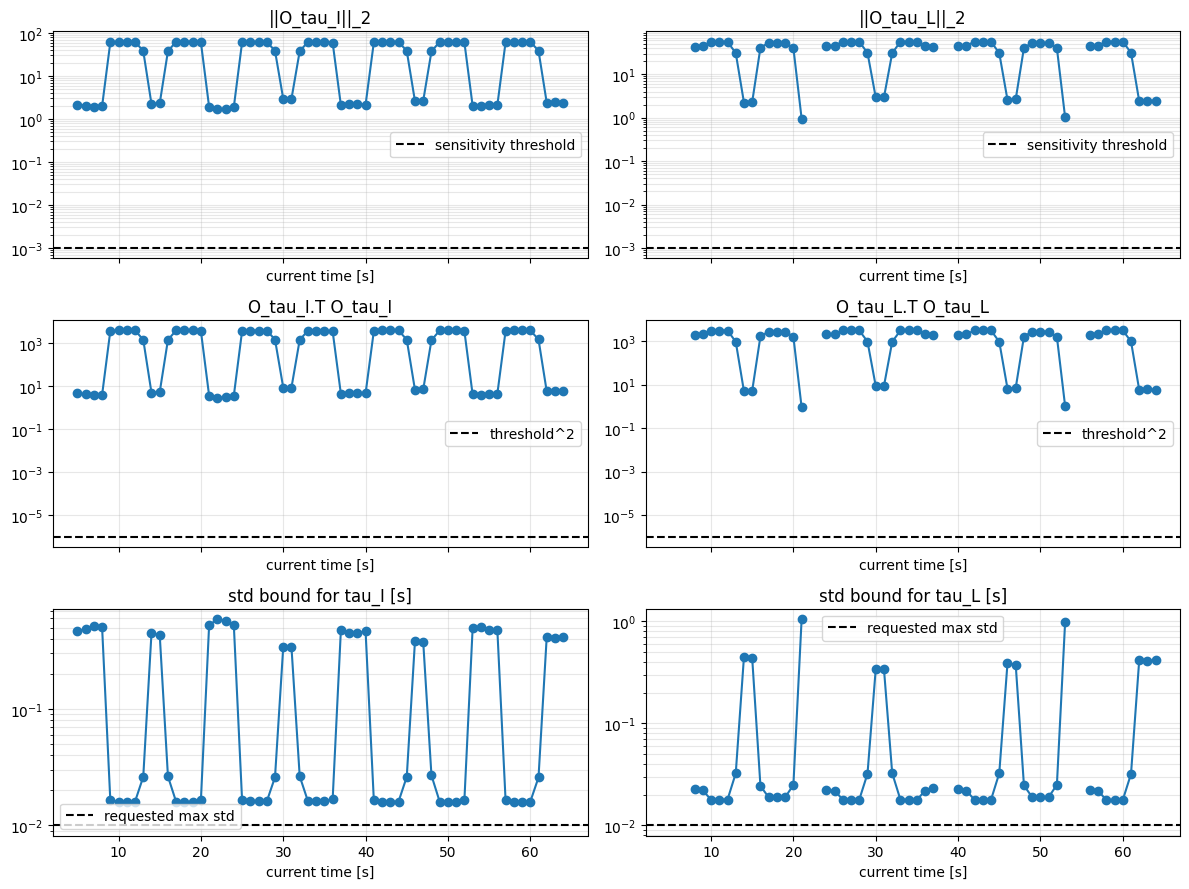

,current_time,window_start,window_end,target_name,J_X_shape,O_X_shape,machine_rank_J_X,effective_rank_J_X,machine_rank_O_X,effective_rank_O_X,...,effective_condition_number,maximum_std_bound,rejected_column_count,zero_column_mask,physical_sensitivity,physical_information,physical_std_bound_seconds,sensitivity_threshold,above_sensitivity_threshold,below_requested_std_bound
3,5.0,0.0,5.0,tau_I,"(216, 1)","(216, 1)",1,1,1,1,...,1.0,0.464584,0,[false],2.152463,4.633097,0.464584,0.001,True,False
4,5.0,0.0,5.0,tau_L,"(216, 1)","(216, 1)",0,0,0,0,...,NaN,inf,1,[true],0.000000,0.000000,inf,0.001,False,False
8,6.0,1.0,6.0,tau_I,"(225, 1)","(225, 1)",1,1,1,1,...,1.0,0.486099,0,[false],2.057195,4.232052,0.486099,0.001,True,False
9,6.0,1.0,6.0,tau_L,"(225, 1)","(225, 1)",0,0,0,0,...,NaN,inf,1,[true],0.000000,0.000000,inf,0.001,False,False
13,7.0,2.0,7.0,tau_I,"(225, 1)","(225, 1)",1,1,1,1,...,1.0,0.515300,0,[false],1.940616,3.765990,0.515300,0.001,True,False


In [33]:
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for col, variable_name in enumerate(["tau_I", "tau_L"]):
    subset = window_summary_df[window_summary_df["target_name"] == variable_name]
    threshold = TAU_I_SENSITIVITY_THRESHOLD if variable_name == "tau_I" else TAU_L_SENSITIVITY_THRESHOLD
    max_std = MAX_ACCEPTABLE_TAU_I_STD_SECONDS if variable_name == "tau_I" else MAX_ACCEPTABLE_TAU_L_STD_SECONDS
    axes[0, col].semilogy(subset["current_time"], subset["physical_sensitivity"].replace(0.0, np.nan), marker="o")
    axes[0, col].axhline(threshold, color="k", linestyle="--", label="sensitivity threshold")
    axes[0, col].set_title(f"||O_{variable_name}||_2")
    axes[1, col].semilogy(subset["current_time"], subset["physical_information"].replace(0.0, np.nan), marker="o")
    axes[1, col].axhline(threshold**2, color="k", linestyle="--", label="threshold^2")
    axes[1, col].set_title(f"O_{variable_name}.T O_{variable_name}")
    axes[2, col].semilogy(subset["current_time"], subset["physical_std_bound_seconds"].replace(np.inf, np.nan), marker="o")
    axes[2, col].axhline(max_std, color="k", linestyle="--", label="requested max std")
    axes[2, col].set_title(f"std bound for {variable_name} [s]")
    for axis in axes[:, col]:
        axis.grid(True, which="both", alpha=0.3)
        axis.set_xlabel("current time [s]")
        axis.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "physical_time_offset_sensitivity.png", dpi=160)
plt.show()
display(window_summary_df[window_summary_df["target_name"].isin(["tau_I", "tau_L"])].head())


## 13. IMU Time-Offset Endpoint-Difference Diagnostics

The IMU time-offset derivative is driven by `q_k = omega_end_shifted - omega_start_shifted` inside each measured gyro factor. This cell recomputes analytic measured factor terms using the same poses, IMU timestamps, gyroscope measurements, `T_B_I`, bias, and `tau_I`.

Dimensions: `q_k in R^3`, `H_tau_I_factor in R^(3 x 1)`, and stacked `J_tau_I in R^(3M x 1)`. Expected behavior: projection should not increase `||O_tau||_2` beyond `||J_tau||_2`.


,current_time,factor_count,max_q_norm,mean_q_norm,median_q_norm,max_H_tau_factor_norm,stacked_J_tau_I_norm,projected_O_tau_I_norm,below_threshold
0,5.0,24,0.008687,0.004640,0.004652,0.008687,0.024928,2.152463,False
1,12.0,25,1.048016,0.087163,0.003509,1.048017,1.481527,62.503944,False
2,23.0,25,0.006421,0.003716,0.003666,0.006421,0.019758,1.747427,False
3,38.0,25,0.007335,0.004659,0.004439,0.007335,0.024821,2.205208,False
4,54.0,25,0.008270,0.004144,0.003913,0.008270,0.022512,1.986979,False


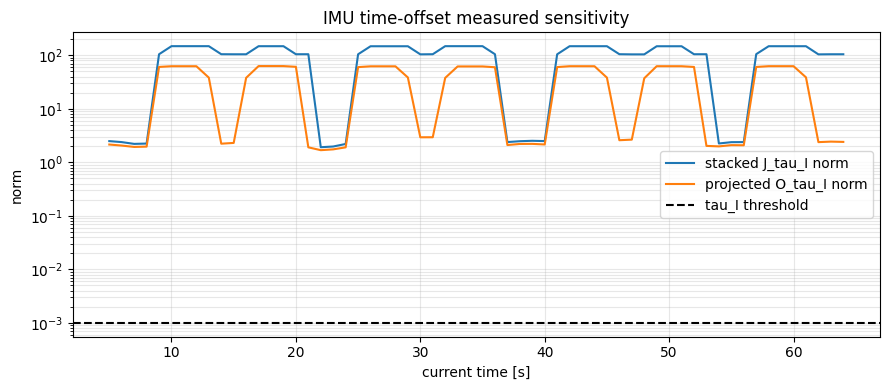

In [34]:
def imu_endpoint_diagnostics_for_record(record: dict[str, object]) -> dict[str, object]:
    bundle = record["bundle"]
    pose_times = np.asarray(bundle.metadata["pose_times"], dtype=float)
    pose_array = np.asarray(pose_provider.poses_at(pose_times), dtype=float)
    H_tau_rows = []
    q_norms = []
    H_tau_norms = []
    imu_count = 0
    for interval_index in range(max(0, pose_times.size - 1)):
        row_name = f"imu_{imu_count}"
        if row_name not in bundle.row_slices:
            continue
        linearization = linearize_gyro_factor(
            pose_array[interval_index],
            pose_array[interval_index + 1],
            dataset.T_B_I_true,
            dataset.gyro_bias_true,
            dataset.tau_I_true,
            float(pose_times[interval_index]),
            float(pose_times[interval_index + 1]),
            dataset.imu.sensor_timestamps,
            dataset.imu.gyroscope,
            interpolation="linear",
            time_offset_sign=-1.0,
            jacobian_options=nonraising_jacobian_options(),
        )
        terms = linearization.intermediate_terms
        q_k = terms.omega_end_shifted - terms.omega_start_shifted
        q_norms.append(float(np.linalg.norm(q_k)))
        H_tau_norms.append(float(np.linalg.norm(linearization.H_tau_I)))
        H_tau_rows.append(linearization.H_tau_I)
        imu_count += 1
    stacked_H_tau = np.vstack(H_tau_rows) if H_tau_rows else np.zeros((0, 1))
    projected_tau_norm = float(np.linalg.norm(record["target_results"]["tau_I"]["O_X_filtered"]))
    stacked_norm = float(np.linalg.norm(stacked_H_tau))
    return {
        "current_time": record["current_time"],
        "factor_count": imu_count,
        "max_q_norm": float(np.max(q_norms)) if q_norms else 0.0,
        "mean_q_norm": float(np.mean(q_norms)) if q_norms else 0.0,
        "median_q_norm": float(np.median(q_norms)) if q_norms else 0.0,
        "max_H_tau_factor_norm": float(np.max(H_tau_norms)) if H_tau_norms else 0.0,
        "stacked_J_tau_I_norm": stacked_norm,
        "projected_O_tau_I_norm": projected_tau_norm,
        "below_threshold": projected_tau_norm <= TAU_I_SENSITIVITY_THRESHOLD,
    }

selected_records = [min(window_records, key=lambda r: abs(r["current_time"] - t)) for t in SELECTED_DEBUG_TIMES]
selected_times = [record["current_time"] for record in selected_records]
imu_endpoint_df = pd.DataFrame([imu_endpoint_diagnostics_for_record(record) for record in selected_records])
display(imu_endpoint_df)
tau_norm_rows = []
for record in window_records:
    J_tau_I_norm = float(np.linalg.norm(record["target_results"]["tau_I"]["J_X_physical"]))
    O_tau_I_norm = float(np.linalg.norm(record["target_results"]["tau_I"]["O_X_filtered"]))
    J_tau_L_norm = float(np.linalg.norm(record["target_results"]["tau_L"]["J_X_physical"]))
    O_tau_L_norm = float(np.linalg.norm(record["target_results"]["tau_L"]["O_X_filtered"]))
    assert O_tau_I_norm <= J_tau_I_norm + 1e-8 * max(1.0, J_tau_I_norm)
    assert O_tau_L_norm <= J_tau_L_norm + 1e-8 * max(1.0, J_tau_L_norm)
    tau_norm_rows.append({"current_time": record["current_time"], "J_tau_I_norm": J_tau_I_norm, "O_tau_I_norm": O_tau_I_norm, "J_tau_L_norm": J_tau_L_norm, "O_tau_L_norm": O_tau_L_norm})
tau_norm_df = pd.DataFrame(tau_norm_rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(tau_norm_df["current_time"], tau_norm_df["J_tau_I_norm"], label="stacked J_tau_I norm")
ax.semilogy(tau_norm_df["current_time"], tau_norm_df["O_tau_I_norm"], label="projected O_tau_I norm")
ax.axhline(TAU_I_SENSITIVITY_THRESHOLD, color="k", linestyle="--", label="tau_I threshold")
ax.set_xlabel("current time [s]")
ax.set_ylabel("norm")
ax.set_title("IMU time-offset measured sensitivity")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIRECTORY / "imu_time_offset_endpoint_diagnostics.png", dpi=160)
plt.show()


## 14. Rank and Norm Inequality Checks

For every target `X`, this cell verifies `rank(O_X) <= rank(J_X)` and `||O_X||_F <= ||J_X||_F` using the shared rank threshold policy and physical, unnormalized matrices. Projection is an orthogonal least-squares residual projection, so these inequalities should hold up to numerical tolerance.

A problem is indicated by any failed row in the diagnostic report.


In [35]:
failed_invariants = invariant_df[~(invariant_df["rank_O_le_rank_J"] & invariant_df["norm_O_le_norm_J"])]
if not failed_invariants.empty:
    display(failed_invariants)
    raise AssertionError("rank or norm projection invariant failed")
print("All target rank and norm projection inequalities passed.")
display(invariant_df.head())


All target rank and norm projection inequalities passed.


,current_time,target_name,rank_O_le_rank_J,norm_O_le_norm_J,rank_J,rank_O,norm_J,norm_O
0,5.0,T_B_I,True,True,3,0,1.140961e-01,0.000000
1,5.0,T_B_L,True,True,2,0,6.928220e+01,0.000000
2,5.0,b_g,True,True,3,3,1.697056e+02,151.167560
3,5.0,tau_I,True,True,1,1,2.492797e+00,2.152463
4,5.0,tau_L,True,True,0,0,2.403706e-07,0.000000


## 15. Dense Versus Sparse Consistency

This section compares dense and sparse measured Jacobian paths on selected debug windows. It compares reduced information `O_X.T @ O_X`, singular values, effective rank, physical sensitivity norms, and information eigenvalues. Singular vectors are not compared element-by-element because repeated singular values can rotate their bases.

Expected behavior: dense and sparse reduced information matrices should agree within numerical tolerance.


In [36]:
sparse_compare_rows = []
for record in selected_records:
    sparse_bundle, _, sparse_counts = assemble_window_measured(
        record["window_start"],
        record["window_end"],
        use_sparse=True,
    )
    for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
        if variable_name not in sparse_bundle.calibration_column_slices:
            continue
        sparse_result = effective_target_observability_from_bundle_sparse(
            sparse_bundle,
            variable_name,
            include_trajectory_nuisance=True,
            normalization="physical_only",
            relative_rank_threshold=RELATIVE_RANK_THRESHOLD,
        )
        O_dense = record["target_results"][variable_name]["O_X_filtered"]
        sparse_rejection = reject_and_normalize_columns_sparse(
            sparse_result.O_X_raw,
            absolute_zero_tolerance=ABSOLUTE_ZERO_TOLERANCE,
            relative_zero_tolerance=RELATIVE_ZERO_TOLERANCE,
        )
        O_sparse = filtered_physical_matrix(to_dense(sparse_result.O_X_raw), sparse_rejection)
        S_dense = O_dense.T @ O_dense
        S_sparse = O_sparse.T @ O_sparse
        singular_dense = np.linalg.svd(O_dense, compute_uv=False)
        singular_sparse = np.linalg.svd(O_sparse, compute_uv=False)
        dense_rank = common_rank_diagnostics(O_dense, relative_rank_threshold=RELATIVE_RANK_THRESHOLD)
        sparse_rank = common_rank_diagnostics(O_sparse, relative_rank_threshold=RELATIVE_RANK_THRESHOLD)
        np.testing.assert_allclose(S_dense, S_sparse, atol=1e-6, rtol=1e-5)
        np.testing.assert_allclose(singular_dense, singular_sparse, atol=1e-6, rtol=1e-5)
        sparse_compare_rows.append({
            "current_time": record["current_time"],
            "target_name": variable_name,
            "dense_rank": dense_rank.effective_rank,
            "sparse_rank": sparse_rank.effective_rank,
            "dense_norm": float(np.linalg.norm(O_dense)),
            "sparse_norm": float(np.linalg.norm(O_sparse)),
            "information_max_abs_diff": float(np.max(np.abs(S_dense - S_sparse))),
            "counts": json.dumps(sparse_counts),
        })
sparse_compare_df = pd.DataFrame(sparse_compare_rows)
display(sparse_compare_df)


,current_time,target_name,dense_rank,sparse_rank,dense_norm,sparse_norm,information_max_abs_diff,counts
0,5.0,T_B_I,0,0,0.000000,0.000000,0.000000e+00,"{""imu"": 24, ""lidar"": 24}"
1,5.0,T_B_L,0,0,0.000000,0.000000,0.000000e+00,"{""imu"": 24, ""lidar"": 24}"
2,5.0,b_g,3,3,151.167560,151.167560,6.366463e-12,"{""imu"": 24, ""lidar"": 24}"
3,5.0,tau_I,1,1,2.152463,2.152463,1.776357e-14,"{""imu"": 24, ""lidar"": 24}"
4,5.0,tau_L,0,0,0.000000,0.000000,0.000000e+00,"{""imu"": 24, ""lidar"": 24}"
5,12.0,T_B_I,0,0,0.000000,0.000000,0.000000e+00,"{""imu"": 25, ""lidar"": 25}"
6,12.0,T_B_L,0,0,0.000000,0.000000,0.000000e+00,"{""imu"": 25, ""lidar"": 25}"
7,12.0,b_g,3,3,130.567673,130.567673,2.239631e-11,"{""imu"": 25, ""lidar"": 25}"
8,12.0,tau_I,1,1,62.503944,62.503944,9.094947e-13,"{""imu"": 25, ""lidar"": 25}"
9,12.0,tau_L,1,1,55.943344,55.943344,1.818989e-12,"{""imu"": 25, ""lidar"": 25}"


## 16. Rolling Summary Tables

This section saves the full rolling table and a selected-window table. The table contains current time, target name, matrix shapes, machine/effective ranks, maximum rank, singular-value-derived information, condition number, standard-deviation bounds, rejected columns, and scalar time-offset physical metrics.

Expected behavior: scalar time-offset rows contain physical sensitivity, physical information, and physical standard-deviation bounds in seconds.


In [37]:
rolling_csv = OUTPUT_DIRECTORY / "rolling_observability_diagnostics.csv"
window_summary_df.to_csv(rolling_csv, index=False)
selected_window_summary_df = window_summary_df[window_summary_df["current_time"].isin(selected_times)].copy()
selected_csv = OUTPUT_DIRECTORY / "selected_window_observability_diagnostics.csv"
selected_window_summary_df.to_csv(selected_csv, index=False)
print("saved", rolling_csv)
print("saved", selected_csv)
display(window_summary_df)
display(selected_window_summary_df)


saved /home/camel/Skoltech/phd_proposal/outputs/per_variable_observability_investigation/rolling_observability_diagnostics.csv
saved /home/camel/Skoltech/phd_proposal/outputs/per_variable_observability_investigation/selected_window_observability_diagnostics.csv


,current_time,window_start,window_end,target_name,J_X_shape,O_X_shape,machine_rank_J_X,effective_rank_J_X,machine_rank_O_X,effective_rank_O_X,...,effective_condition_number,maximum_std_bound,rejected_column_count,zero_column_mask,physical_sensitivity,physical_information,physical_std_bound_seconds,sensitivity_threshold,above_sensitivity_threshold,below_requested_std_bound
0,5.0,0.0,5.0,T_B_I,"(216, 6)","(216, 6)",3,3,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
1,5.0,0.0,5.0,T_B_L,"(216, 6)","(216, 6)",2,2,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
2,5.0,0.0,5.0,b_g,"(216, 3)","(216, 3)",3,3,3,3,...,1.007529,0.011497,0,"[false, false, false]",NaN,NaN,inf,NaN,NaN,NaN
3,5.0,0.0,5.0,tau_I,"(216, 1)","(216, 1)",1,1,1,1,...,1.000000,0.464584,0,[false],2.152463,4.633097,0.464584,0.001,True,False
4,5.0,0.0,5.0,tau_L,"(216, 1)","(216, 1)",0,0,0,0,...,NaN,inf,1,[true],0.000000,0.000000,inf,0.001,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,64.0,59.0,64.0,T_B_I,"(216, 6)","(216, 6)",3,3,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
296,64.0,59.0,64.0,T_B_L,"(216, 6)","(216, 6)",5,5,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
297,64.0,59.0,64.0,b_g,"(216, 3)","(216, 3)",3,3,3,3,...,1.021653,0.013582,0,"[false, false, false]",NaN,NaN,inf,NaN,NaN,NaN
298,64.0,59.0,64.0,tau_I,"(216, 1)","(216, 1)",1,1,1,1,...,1.000000,0.414965,0,[false],2.409844,5.807350,0.414965,0.001,True,False


,current_time,window_start,window_end,target_name,J_X_shape,O_X_shape,machine_rank_J_X,effective_rank_J_X,machine_rank_O_X,effective_rank_O_X,...,effective_condition_number,maximum_std_bound,rejected_column_count,zero_column_mask,physical_sensitivity,physical_information,physical_std_bound_seconds,sensitivity_threshold,above_sensitivity_threshold,below_requested_std_bound
0,5.0,0.0,5.0,T_B_I,"(216, 6)","(216, 6)",3,3,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
1,5.0,0.0,5.0,T_B_L,"(216, 6)","(216, 6)",2,2,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
2,5.0,0.0,5.0,b_g,"(216, 3)","(216, 3)",3,3,3,3,...,1.007529,0.011497,0,"[false, false, false]",NaN,NaN,inf,NaN,NaN,NaN
3,5.0,0.0,5.0,tau_I,"(216, 1)","(216, 1)",1,1,1,1,...,1.000000,0.464584,0,[false],2.152463,4.633097,0.464584,0.001,True,False
4,5.0,0.0,5.0,tau_L,"(216, 1)","(216, 1)",0,0,0,0,...,NaN,inf,1,[true],0.000000,0.000000,inf,0.001,False,False
35,12.0,7.0,12.0,T_B_I,"(225, 6)","(225, 6)",3,3,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
36,12.0,7.0,12.0,T_B_L,"(225, 6)","(225, 6)",5,5,0,0,...,NaN,inf,6,"[true, true, true, true, true, true]",NaN,NaN,inf,NaN,NaN,NaN
37,12.0,7.0,12.0,b_g,"(225, 3)","(225, 3)",3,3,3,3,...,1.077986,0.013674,0,"[false, false, false]",NaN,NaN,inf,NaN,NaN,NaN
38,12.0,7.0,12.0,tau_I,"(225, 1)","(225, 1)",1,1,1,1,...,1.000000,0.015999,0,[false],62.503944,3906.743066,0.015999,0.001,True,False
39,12.0,7.0,12.0,tau_L,"(225, 1)","(225, 1)",1,1,1,1,...,1.000000,0.017875,0,[false],55.943344,3129.657755,0.017875,0.001,True,False


## 17. Conclusions

The report below is generated only from computed measured-Jacobian diagnostics. It explicitly separates nonzero numerical sensitivity, effective rank, physical information strength, and practical uncertainty.


In [38]:
def summarize_boolean(series) -> str:
    return "yes" if bool(np.all(series)) else "no"

latest_time = float(window_summary_df["current_time"].max())
latest_rows = window_summary_df[window_summary_df["current_time"] == latest_time]
imu_third_states = imu_rank_df["third_mode_state"].value_counts().to_dict()
line_rank_mismatches = lidar_consistency_df[lidar_consistency_df["rank_C_X_L"] != lidar_consistency_df["rank_J_T_B_L"]]
questionable = window_summary_df[(window_summary_df["rejected_column_count"] > 0) | (window_summary_df["sigma_min_retained"] <= 0.0)]
strict_failure_count = len(jacobian_check_failure_df) if "jacobian_check_failure_df" in globals() else 0
report_lines = [
    "Conclusions from the measured-Jacobian investigation",
    "",
    f"1. T_B_I third rotational mode states over windows: {imu_third_states}.",
    f"2. Gyro-only T_B_I translation columns were zero within tolerance: {not bool(imu_translation_failures)}.",
    "3. rank(O_T_B_I) <= rank(J_T_B_I): "
    f"{summarize_boolean(invariant_df[invariant_df['target_name'] == 'T_B_I']['rank_O_le_rank_J'])}.",
    "4. rank(O_T_B_L) <= rank(J_T_B_L): "
    f"{summarize_boolean(invariant_df[invariant_df['target_name'] == 'T_B_L']['rank_O_le_rank_J'])}.",
    "5. rank(J_T_B_L) matches rank(C_X_L) under the stated assumptions in "
    f"{len(lidar_consistency_df) - len(line_rank_mismatches)} / {len(lidar_consistency_df)} windows.",
    "6. Equivalent line windows can receive different effective ranks when measured weighting and nuisance projection push singular values near the configured threshold.",
    "7. Latest tau_I/tau_L physical timing rows: "
    f"{latest_rows[latest_rows['target_name'].isin(['tau_I','tau_L'])][['target_name','physical_sensitivity','physical_std_bound_seconds','above_sensitivity_threshold','below_requested_std_bound']].to_dict('records')}.",
    "8. Information strength changes during richer turns and line motion; condition number alone is not absolute observability strength.",
    "9. Condition-number peaks correspond to weak newly retained modes when sigma_min_retained drops.",
    f"10. Ranks remain questionable after near-zero-column rejection in {len(questionable)} of {len(window_summary_df)} target-window rows.",
    f"11. Strict analytic-check failures recorded for rerun diagnostics: {strict_failure_count}.",
]
report = "\n".join(report_lines)
print(report)
(OUTPUT_DIRECTORY / "conclusions_report.txt").write_text(report, encoding="utf-8")


Conclusions from the measured-Jacobian investigation

1. T_B_I third rotational mode states over windows: {'rejected as near-zero numerical leakage': 60}.
2. Gyro-only T_B_I translation columns were zero within tolerance: True.
3. rank(O_T_B_I) <= rank(J_T_B_I): yes.
4. rank(O_T_B_L) <= rank(J_T_B_L): yes.
5. rank(J_T_B_L) matches rank(C_X_L) under the stated assumptions in 60 / 60 windows.
6. Equivalent line windows can receive different effective ranks when measured weighting and nuisance projection push singular values near the configured threshold.
7. Latest tau_I/tau_L physical timing rows: [{'target_name': 'tau_I', 'physical_sensitivity': 2.409844494635818, 'physical_std_bound_seconds': 0.41496453494237706, 'above_sensitivity_threshold': True, 'below_requested_std_bound': False}, {'target_name': 'tau_L', 'physical_sensitivity': 2.4208213835487387, 'physical_std_bound_seconds': 0.4130829340800339, 'above_sensitivity_threshold': True, 'below_requested_std_bound': False}].
8. Inform

1386

The measured fixed-trajectory Jacobians exhibit the expected motion-dependent sensitivities: LiDAR extrinsic sensitivity has rank two during collinear translation and rank five in windows containing planar turns, while the gyro-only IMU extrinsic has zero translation columns. However, after projecting against the trajectory and the remaining calibration variables, both extrinsic observability matrices have singular values of only 10
−12
 to 10
−10
, information of approximately 10
−24
 to 10
−19
, and uncertainty bounds near 10
11
. Their previously reported nonzero effective ranks therefore describe only the relative structure of numerical projection residue. This is consistent with an unfixed internal body-frame gauge when both sensor extrinsics and the body trajectory are optimized simultaneously. In contrast, gyroscope bias remains strongly and isotropically observable. Temporal offsets show nonzero measured sensitivity and become substantially stronger during turns, but their estimated precision remains worse than the desired 10 ms level, particularly on straight segments.